In [13]:
# --- Config (edit these) ---
CSV_A       = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B       = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
IDS_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS_TSV = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

SEED, VAL_SPLIT, TEST_SPLIT = 42, 0.15, 0.15
CLIP_Q = (0.001, 0.999)

# --- Imports ---
import math, random, re
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
random.seed(SEED); np.random.seed(SEED)

In [14]:
# --- Helpers ---
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing: raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS: df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def engineered_features(df_a, df_b, ids):
    A = df_a.loc[ids, FEATURE_COLS].to_numpy(dtype=np.float64)
    B = df_b.loc[ids, FEATURE_COLS].to_numpy(dtype=np.float64)
    SUM, DIFF = A + B, A - B
    ADIFF, PROD = np.abs(DIFF), A * B
    COS = ((A * B).sum(axis=1) /
           (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + 1e-8)).reshape(-1,1)
    return np.hstack([A, B, SUM, DIFF, ADIFF, PROD, COS])

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}


In [15]:
# --- Load features & ID list ---
df_a, df_b = load_feature_csv(CSV_A), load_feature_csv(CSV_B)
ids_txt = [normalize_pdb_id(x) for x in Path(IDS_TXT).read_text().splitlines() if x.strip()]
df_ids = pd.DataFrame({"JOIN_ID": ids_txt}).drop_duplicates(ignore_index=True)

# --- Load targets (for training) ---
df_t = pd.read_csv(TARGETS_TSV, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
for c in ("pdb_id","delta_G"):
    if c not in df_t.columns: raise ValueError("Targets must have 'pdb_id' and 'delta_G'.")
df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# --- Intersect: TXT IDs ∩ A ∩ B ∩ targets ---
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"]) & set(df_ids["JOIN_ID"])
print(f"TXT IDs: {len(ids_txt)} | Common usable: {len(common)}")
if not common: raise RuntimeError("No overlap between ids.txt, features (A/B), and targets.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

# Order everything by target rows (so X matches y)
order_ids = df_t["JOIN_ID"]
X_all = engineered_features(df_a, df_b, order_ids)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1)

TXT IDs: 979 | Common usable: 979


In [16]:
# --- Split train/val/test ---
X_tmp, X_te, y_tmp, y_te = train_test_split(X_all, y_all, test_size=TEST_SPLIT, random_state=SEED, shuffle=True)
val_share = VAL_SPLIT / (1.0 - TEST_SPLIT)
X_tr, X_va, y_tr, y_va = train_test_split(X_tmp, y_tmp, test_size=val_share, random_state=SEED, shuffle=True)

# --- Robust clip on TRAIN only (and apply to val/test) ---
if CLIP_Q:
    lo_tr, hi_tr = np.nanquantile(X_tr, CLIP_Q, axis=0)
    clip = lambda X: np.clip(X, lo_tr, hi_tr)
    X_tr, X_va, X_te = clip(X_tr), clip(X_va), clip(X_te)

# --- Quantile transform (stabilizes NN) ---
qt = QuantileTransformer(n_quantiles=min(1000, max(10, len(X_tr))), random_state=SEED, output_distribution="normal")
X_tr_s, X_va_s, X_te_s = qt.fit_transform(X_tr), qt.transform(X_va), qt.transform(X_te)

# --- Neural net (MLP) with a few tested configs; pick best on VAL MSE ---
candidates = [
    dict(hidden_layer_sizes=(256,128), alpha=1e-4, learning_rate_init=1e-3, batch_size=64),
    dict(hidden_layer_sizes=(512,256), alpha=1e-4, learning_rate_init=5e-4, batch_size=128),
    dict(hidden_layer_sizes=(256,256,128), alpha=3e-4, learning_rate_init=1e-3, batch_size=128),
]
best = (float("inf"), None, None)

from sklearn.neural_network import MLPRegressor
for p in candidates:
    mlp = MLPRegressor(
        hidden_layer_sizes=p["hidden_layer_sizes"], activation="relu", solver="adam",
        alpha=p["alpha"], learning_rate="adaptive", learning_rate_init=p["learning_rate_init"],
        batch_size=p["batch_size"], max_iter=4000, early_stopping=True,
        n_iter_no_change=40, validation_fraction=0.15, random_state=SEED, verbose=False
    )
    mlp.fit(X_tr_s, y_tr)
    val_mse = mean_squared_error(y_va, mlp.predict(X_va_s))
    if val_mse < best[0]: best = (val_mse, p, mlp)

print(f"[MLP] Best VAL MSE={best[0]:.4f} with params={best[1]}")


[MLP] Best VAL MSE=93.5928 with params={'hidden_layer_sizes': (512, 256), 'alpha': 0.0001, 'learning_rate_init': 0.0005, 'batch_size': 128}


[MLP*] Test | MSE 109.6662  MAE 7.873  RMSE 10.472  R2 0.118


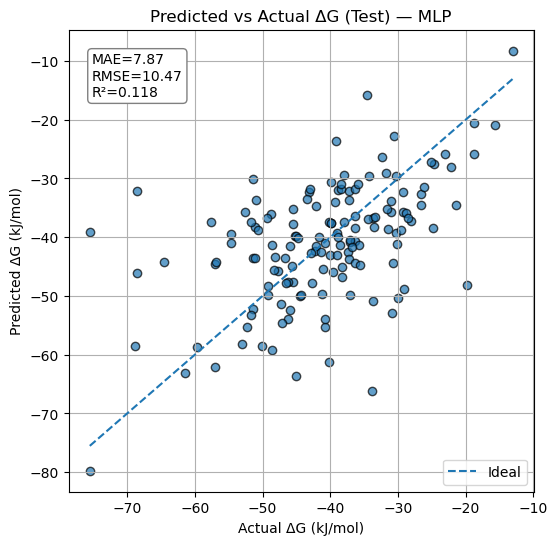

In [17]:
# --- Refit best on TRAIN+VAL, evaluate on TEST ---
from sklearn.neural_network import MLPRegressor
mlp_best = MLPRegressor(
    hidden_layer_sizes=best[1]["hidden_layer_sizes"], activation="relu", solver="adam",
    alpha=best[1]["alpha"], learning_rate="adaptive", learning_rate_init=best[1]["learning_rate_init"],
    batch_size=best[1]["batch_size"], max_iter=4000, early_stopping=False, random_state=SEED, verbose=False
).fit(np.vstack([X_tr_s, X_va_s]), np.hstack([y_tr, y_va]))

pred_te = mlp_best.predict(X_te_s)
metrics = {
    "MSE": mean_squared_error(y_te, pred_te),
    "MAE": mean_absolute_error(y_te, pred_te),
    "RMSE": math.sqrt(mean_squared_error(y_te, pred_te)),
    "R2": r2_score(y_te, pred_te),
}
print(f"[MLP*] Test | MSE {metrics['MSE']:.4f}  MAE {metrics['MAE']:.3f}  "
      f"RMSE {metrics['RMSE']:.3f}  R2 {metrics['R2']:.3f}")

# --- Plot Pred vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
mn, mx = float(np.min(y_te)), float(np.max(y_te))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
plt.title("Predicted vs Actual ΔG (Test) — MLP")
txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True); plt.show()

In [24]:
# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)


[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
A: (2570, 94) B: (2570, 94) Targets: (979, 8) Common: 979
Shapes -> X_tr:(687, 567), X_va:(146, 567), X_te:(146, 567), y_tr:(687,)

== Metrics ==
Train: {'MSE': 1.6732, 'MAE': 0.6592, 'RMSE': 1.2935, 'R2': 0.9865}
Valid: {'MSE': 96.4194, 'MAE': 7.9643, 'RMSE': 9.8193, 'R2': 0.2783}
Test : {'MSE': 72.2637, 'MAE': 6.7167, 'RMSE': 8.5008, 'R2': 0.3452}


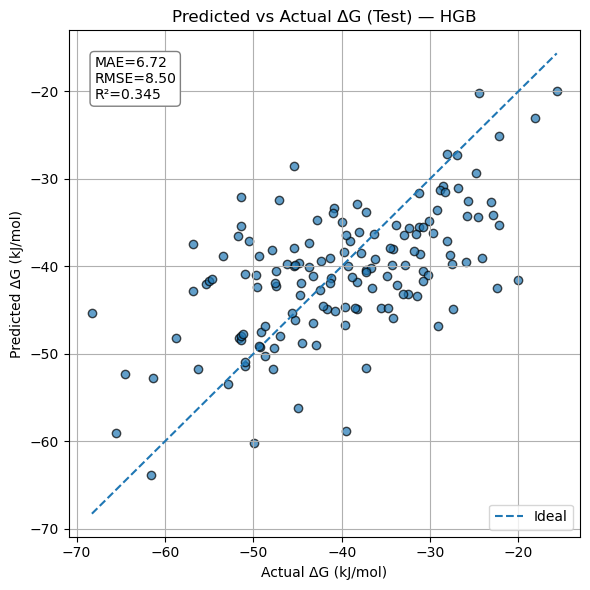

[INFO] Saved plot to: runs/dg_simple_best/pred_vs_actual_test.png


In [ ]:
# 1) Imports & Config

import math, random, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
IDS_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS_TSV = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED       = 42
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
CLIP_Q     = (0.001, 0.999)   # robust feature clipping
USE_BFACT  = True             # add Avg_Bfactor_Total / Avg_Bfactor_Interface if present

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    """Load one PDB ID per line; ignores blanks and lines starting with #; normalizes to 4-char lowercase."""
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    # average duplicates per normalized ID
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = math.sqrt(mse)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load & align data

# Features
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

# Targets
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
# standardize headings
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

need = ["pdb_id", "delta_G"]
for c in need:
    if c not in df_t.columns: 
        raise ValueError(f"targets must contain '{c}' (have: {list(df_t.columns)})")

extra_cols = []
if USE_BFACT:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- NEW: limit to IDs present in the TXT list
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")

if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list. Check your ids.txt and target PDB IDs.")

# keep only IDs present in both A and B
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"])
dropped = len(df_t) - sum(df_t["JOIN_ID"].isin(common))
if dropped:
    print(f"[INFO] Dropping {dropped} target rows not present in both feature tables A & B.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

print("A:", df_a.shape, "B:", df_b.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 3:
    print("[WARN] Very few samples after filtering—train/val/test split may be degenerate.")

# 4) Features + split

# base matrices aligned to df_t (order matters!)
A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

# engineered interactions
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS]

if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts)

# split indices
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(max(1, n*TEST_SPLIT)) if n >= 5 else max(1, int(n*TEST_SPLIT))
n_val  = int(max(1, n*VAL_SPLIT)) if n >= 6 else max(0, int(n*VAL_SPLIT))

# guard to avoid overlap
n_test = min(n_test, n-1) if n > 2 else max(0, n-2)
n_val  = min(n_val,  n-1-n_test)

test_idx = idx[:n_test]
val_idx  = idx[n_test:n_test+n_val]
train_idx= idx[n_test+n_val:]

if len(train_idx) == 0:
    # fallback: put at least one sample in train if possible
    if len(val_idx) > 0:
        train_idx.append(val_idx.pop())
    elif len(test_idx) > 0:
        train_idx.append(test_idx.pop())

X_tr, y_tr = X_all[train_idx], y_all[train_idx].ravel()
X_va, y_va = X_all[val_idx],   y_all[val_idx].ravel() if len(val_idx) else (np.empty((0, X_all.shape[1])), np.array([]))
X_te, y_te = X_all[test_idx],  y_all[test_idx].ravel() if len(test_idx) else (np.empty((0, X_all.shape[1])), np.array([]))

# robust clipping (no standardization; trees handle scales fine)
if CLIP_Q is not None and len(X_tr) > 0:
    lo_tr, hi_tr = np.nanquantile(X_tr, CLIP_Q, axis=0)
    def clip(X): 
        if X.size == 0: return X
        return np.clip(X, lo_tr, hi_tr)
    X_tr, X_va, X_te = clip(X_tr), clip(X_va), clip(X_te)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# 5) Train model

model = HistGradientBoostingRegressor(random_state=SEED)
model.fit(X_tr, y_tr)

# 6) Evaluate

def safe_predict(m, X):
    return m.predict(X) if X.size else np.array([])

pred_tr = safe_predict(model, X_tr)
metrics_tr = compute_metrics(y_tr, pred_tr)

if X_va.size:
    pred_va = model.predict(X_va)
    metrics_va = compute_metrics(y_va, pred_va)
else:
    pred_va, metrics_va = np.array([]), {"MSE": np.nan, "MAE": np.nan, "RMSE": np.nan, "R2": np.nan}

if X_te.size:
    pred_te = model.predict(X_te)
    metrics_te = compute_metrics(y_te, pred_te)
else:
    pred_te, metrics_te = np.array([]), {"MSE": np.nan, "MAE": np.nan, "RMSE": np.nan, "R2": np.nan}

print("\n== Metrics ==")
print("Train:", {k: round(v, 4) for k, v in metrics_tr.items()})
print("Valid:", {k: (None if np.isnan(v) else round(v, 4)) for k, v in metrics_va.items()})
print("Test :", {k: (None if np.isnan(v) else round(v, 4)) for k, v in metrics_te.items()})

# 7) Plot (Test set)

if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title("Predicted vs Actual ΔG (Test) — HGB")
    txt = f"MAE={metrics_te['MAE']:.2f}\nRMSE={metrics_te['RMSE']:.2f}\nR²={metrics_te['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)

    plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200)
    plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


[INFO] Using 930/2800 target rows present in TXT (930 allowed IDs).
A: (2570, 94) B: (2570, 94) Targets: (930, 8) Common: 930
Shapes -> X_fit:(791, 567) (train+val), X_te:(139, 567), y_fit:(791,)

== Metrics ==
Train+Val (fit): {'MSE': 32.6069, 'MAE': 4.105, 'RMSE': 5.7102, 'R2': 0.7437}
Test: {'MSE': 76.3598, 'MAE': 6.8343, 'RMSE': 8.7384, 'R2': 0.3562}


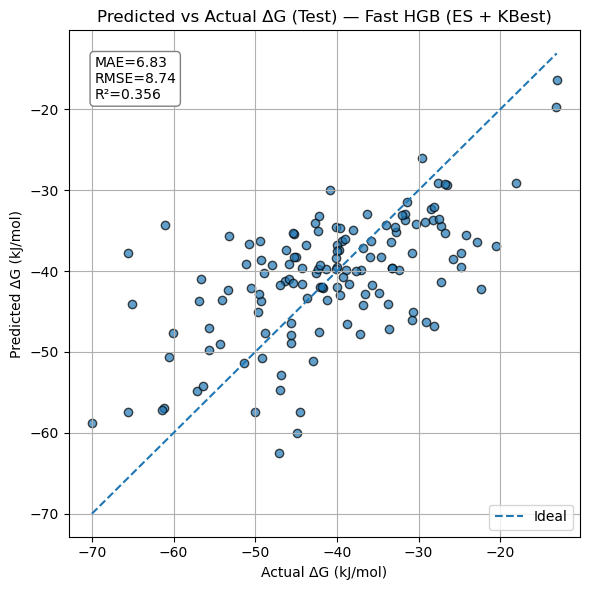

[INFO] Saved plot to: runs/dg_simple_best/pred_vs_actual_test_fast.png


In [6]:
# ============================================
# Fast, Regularized HGB w/ Early Stopping
# ============================================

# 1) Imports & Config

import math, random, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"   # columns: ID + feature_1..feature_94
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"   # columns: ID + feature_1..feature_94
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED       = 42
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
USE_BFACT  = True

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = math.sqrt(mse)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load & align data

df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns: 
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACT:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# Filter by TXT list
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# Keep only IDs present in both feature tables
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"])
dropped = len(df_t) - sum(df_t["JOIN_ID"].isin(common))
if dropped:
    print(f"[INFO] Dropping {dropped} target rows not present in both feature tables A & B.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

print("A:", df_a.shape, "B:", df_b.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# 4) Feature matrix + splits

A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS]
if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts)
y_all = y_all.ravel()

# Holdout splits (as before)
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(n*TEST_SPLIT); n_val = int(n*VAL_SPLIT)
test_idx = idx[:n_test]; val_idx = idx[n_test:n_test+n_val]; train_idx = idx[n_test+n_val:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

# We'll fit on TRAIN+VAL and let the model do its own early-stopping split
X_fit = np.vstack([X_tr, X_va]) if len(X_va) else X_tr
y_fit = np.concatenate([y_tr, y_va]) if len(y_va) else y_tr

print(f"Shapes -> X_fit:{X_fit.shape} (train+val), X_te:{X_te.shape}, y_fit:{y_fit.shape}")

# 5) Pipeline: Impute -> KBest(f_regression) -> HistGBR w/ early stopping

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("kbest",   SelectKBest(score_func=f_regression, k=min(256, X_fit.shape[1]))),
    ("hgb",     HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.07,
        max_depth=4,                 # shallow trees to reduce variance
        max_leaf_nodes=63,           # controls complexity
        min_samples_leaf=30,         # stronger regularization
        l2_regularization=0.3,       # shrink weights
        max_bins=255,
        early_stopping=True,
        validation_fraction=0.15,    # internal split from X_fit
        n_iter_no_change=30,
        max_iter=1000,               # will stop early
        random_state=SEED
    ))
])

pipe.fit(X_fit, y_fit)

# 6) Evaluate

def eval_and_print(X, y, name):
    pred = pipe.predict(X) if X.size else np.array([])
    if pred.size == 0:
        print(f"{name}: [no samples]")
        return None, None
    m = {
        "MSE": float(np.mean((pred - y)**2)),
        "MAE": float(np.mean(np.abs(pred - y))),
        "RMSE": float(np.sqrt(np.mean((pred - y)**2))),
        "R2": float(r2_score(y, pred)),
    }
    print(f"{name}: " + str({k: round(v, 4) for k, v in m.items()}))
    return pred, m

print("\n== Metrics ==")
_ , _ = eval_and_print(X_fit, y_fit, "Train+Val (fit)")
pred_te, metrics_te = eval_and_print(X_te,  y_te,  "Test")

# 7) Plot (Test)
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title("Predicted vs Actual ΔG (Test) — Fast HGB (ES + KBest)")
    txt = f"MAE={metrics_te['MAE']:.2f}\nRMSE={metrics_te['RMSE']:.2f}\nR²={metrics_te['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test_fast.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
A: (2570, 94) B: (2570, 94) Targets: (979, 8) Common: 979
Shapes -> X_fit:(833, 661) (train+val), X_te:(146, 661), y_fit:(833,)

== Metrics ==
Train+Val (fit): {'MSE': 65.3065, 'MAE': 5.5462, 'RMSE': 8.0812, 'R2': 0.4801}
Test: {'MSE': 77.646, 'MAE': 7.0425, 'RMSE': 8.8117, 'R2': 0.2964}


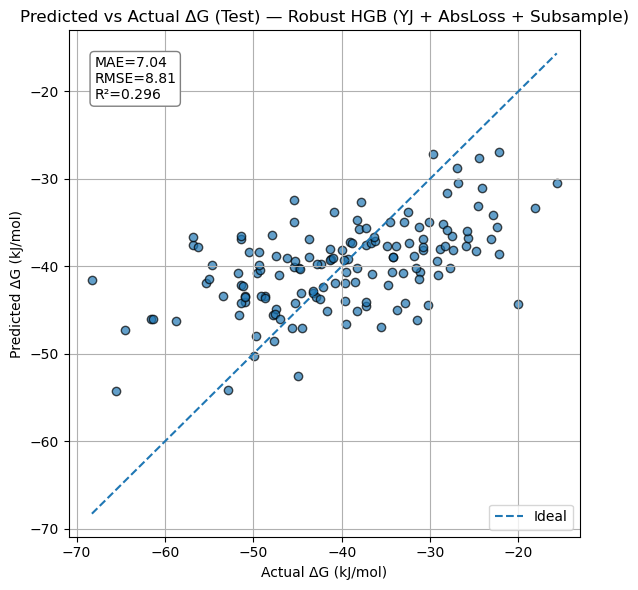

[INFO] Saved plot to: runs/dg_simple_best/pred_vs_actual_test_robust.png


In [37]:
# ============================================
# Robust HGB: Yeo–Johnson target + abs loss + subsampling
# ============================================

# 1) Imports & Config

import math, random, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED       = 42
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
USE_BFACT  = True
CLIP_Y_Q   = None   # e.g., (0.01, 0.99) to winsorize extreme ΔG outliers; keep None to disable

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = math.sqrt(mse)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load & align data

df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACT:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# Filter by TXT list
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# Keep only IDs present in both feature tables
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"])
dropped = len(df_t) - sum(df_t["JOIN_ID"].isin(common))
if dropped:
    print(f"[INFO] Dropping {dropped} target rows not present in both feature tables A & B.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

print("A:", df_a.shape, "B:", df_b.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# 4) Feature matrix + splits

A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

# engineered interactions
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)   # extra stable interaction

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO]
if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts)
y_all = y_all.ravel()

# Optional: winsorize y to reduce extreme outlier influence
if CLIP_Y_Q is not None:
    qlo, qhi = np.quantile(y_all, CLIP_Y_Q)
    y_all = np.clip(y_all, qlo, qhi)

# Holdout splits (as before)
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(n*TEST_SPLIT); n_val = int(n*VAL_SPLIT)
test_idx = idx[:n_test]; val_idx = idx[n_test:n_test+n_val]; train_idx = idx[n_test+n_val:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

# Fit on TRAIN+VAL (internal val for early stopping happens inside the regressor)
X_fit = np.vstack([X_tr, X_va]) if len(X_va) else X_tr
y_fit = np.concatenate([y_tr, y_va]) if len(y_va) else y_tr

print(f"Shapes -> X_fit:{X_fit.shape} (train+val), X_te:{X_te.shape}, y_fit:{y_fit.shape}")

# 5) Pipeline + Target transform
# Yeo–Johnson transforms y (supports negatives) to stabilize variance/heavy tails.

inner = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("kbest",   SelectKBest(score_func=f_regression, k=min(320, X_fit.shape[1]))),
   ("hgb", HistGradientBoostingRegressor(
    loss="absolute_error",      # robust to outliers
    learning_rate=0.05,
    max_depth=3,
    max_leaf_nodes=63,
    min_samples_leaf=50,
    l2_regularization=1.0,
    max_bins=255,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    max_iter=1500,              # will stop earlier
    random_state=SEED
))

])

pipe = TransformedTargetRegressor(
    regressor=inner,
    transformer=PowerTransformer(method="yeo-johnson", standardize=True),
    check_inverse=False
)

pipe.fit(X_fit, y_fit)

# 6) Evaluate

def eval_and_print(model, X, y, name):
    if X.size == 0:
        print(f"{name}: [no samples]")
        return None, None
    pred = model.predict(X)
    m = {
        "MSE": float(np.mean((pred - y)**2)),
        "MAE": float(np.mean(np.abs(pred - y))),
        "RMSE": float(np.sqrt(np.mean((pred - y)**2))),
        "R2": float(r2_score(y, pred)),
    }
    print(f"{name}: " + str({k: round(v, 4) for k, v in m.items()}))
    return pred, m

print("\n== Metrics ==")
_      , _       = eval_and_print(pipe, X_fit, y_fit, "Train+Val (fit)")
pred_te, metrics = eval_and_print(pipe, X_te,  y_te,  "Test")

# 7) Plot (Test)
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title("Predicted vs Actual ΔG (Test) — Robust HGB (YJ + AbsLoss + Subsample)")
    txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test_robust.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


In [ ]:
# ============================================
# ΔG model: TXT-ID filter + feature eng + fast model selection
# ============================================

# 1) Imports & Config

import math, random, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                       = 42
VAL_SPLIT                  = 0.15
TEST_SPLIT                 = 0.15
USE_BFACTORS_AS_FEATURES   = True   # <- like the original model
K_BEST                      = None   # if None -> will pick min(384, n_features)
random.seed(SEED); np.random.seed(SEED)

# 2) Utilities

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = math.sqrt(mse)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load & align data

df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACTORS_AS_FEATURES:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# Filter by TXT list
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# Keep only IDs present in both feature tables
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"])
dropped = len(df_t) - sum(df_t["JOIN_ID"].isin(common))
if dropped:
    print(f"[INFO] Dropping {dropped} target rows not present in both feature tables A & B.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

print("A:", df_a.shape, "B:", df_b.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# 4) Feature matrix + splits

A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

# engineered interactions
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO]
if USE_BFACTORS_AS_FEATURES and extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts)
y_all = y_all.ravel()

# Holdout splits
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(n*TEST_SPLIT); n_val = int(n*VAL_SPLIT)
test_idx = idx[:n_test]; val_idx = idx[n_test:n_test+n_val]; train_idx = idx[n_test+n_val:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# 5) Pipelines (same preprocessing across models)

n_feat = X_tr.shape[1]
k_use  = min(384, n_feat) if K_BEST is None else min(K_BEST, n_feat)

def make_hgb():
    return Pipeline(steps=[
        ("imp",  SimpleImputer(strategy="median")),
        ("k",    SelectKBest(score_func=f_regression, k=k_use)),
        ("hgb",  HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.07,
            max_depth=4,
            max_leaf_nodes=63,
            min_samples_leaf=30,
            l2_regularization=0.3,
            max_bins=255,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            max_iter=1500,
            random_state=SEED
        ))
    ])

def make_gbr():
    return Pipeline(steps=[
        ("imp",  SimpleImputer(strategy="median")),
        ("k",    SelectKBest(score_func=f_regression, k=k_use)),
        ("gbr",  GradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.03,
            n_estimators=1200,    # small lr, more trees
            subsample=0.7,        # row subsampling -> variance reduction
            max_depth=3,
            min_samples_leaf=20,
            random_state=SEED,
            validation_fraction=0.15,
            n_iter_no_change=30,
            tol=1e-4
        ))
    ])

def make_rf():
    return Pipeline(steps=[
        ("imp",  SimpleImputer(strategy="median")),
        ("k",    SelectKBest(score_func=f_regression, k=k_use)),
        ("rf",   RandomForestRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=3,
            n_jobs=-1,
            random_state=SEED
        ))
    ])

candidates = {
    "HGB": make_hgb(),
    "GBR": make_gbr(),
    "RF" : make_rf(),
}

# 6) Train on TRAIN, pick by VAL R2, then refit best on TRAIN+VAL

def fit_eval(model, Xtr, ytr, Xva, yva, name):
    model.fit(Xtr, ytr)
    pred_va = model.predict(Xva) if Xva.size else np.array([])
    r2 = float(r2_score(yva, pred_va)) if pred_va.size else float("nan")
    print(f"[VAL] {name} R2={r2:.4f}")
    return r2, model

best_name, best_r2, best_model = None, -1e9, None
for name, mdl in candidates.items():
    r2, trained = fit_eval(mdl, X_tr, y_tr, X_va, y_va, name)
    if r2 > best_r2:
        best_name, best_r2, best_model = name, r2, trained

print(f"\n[SELECT] Best by VAL: {best_name} (R2={best_r2:.4f})")

# Refit best on TRAIN+VAL
X_fit = np.vstack([X_tr, X_va])
y_fit = np.concatenate([y_tr, y_va])

# remake the best pipeline fresh and fit on combined data
if best_name == "HGB":
    final_model = make_hgb()
elif best_name == "GBR":
    final_model = make_gbr()
else:
    final_model = make_rf()

final_model.fit(X_fit, y_fit)

# 7) Evaluate

def eval_and_print(model, X, y, name):
    pred = model.predict(X) if X.size else np.array([])
    m = {
        "MSE": float(np.mean((pred - y)**2)),
        "MAE": float(np.mean(np.abs(pred - y))),
        "RMSE": float(np.sqrt(np.mean((pred - y)**2))),
        "R2": float(r2_score(y, pred)),
    }
    print(f"{name}: " + str({k: round(v, 4) for k, v in m.items()}))
    return pred, m

print("\n== Metrics ==")
_      , _       = eval_and_print(final_model, X_fit, y_fit, f"Train+Val ({best_name})")
pred_te, metrics = eval_and_print(final_model, X_te,  y_te,  f"Test ({best_name})")

# 8) Plot (Test)
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔG (Test) — {best_name}")
    txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


In [ ]:
# ============================================
# ΔG Ensemble: TXT-ID filter + feature eng + StackingRegressor
# ============================================

# 1) Imports & Config

import math, random, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
)
from sklearn.linear_model import RidgeCV

# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"


OUT_DIR = "./runs/dg_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                         = 42
VAL_SPLIT                    = 0.15
TEST_SPLIT                   = 0.15
USE_BFACTORS_AS_FEATURES     = True  # like your original
K_BEST                        = 448   # good tradeoff for ~600 cols; try 512 if RF dominates
WINSORIZE_Y_QUANTILES         = None  # e.g., (0.01, 0.99) to clip extreme ΔG; keep None to disable

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = math.sqrt(mse)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load & align data

df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACTORS_AS_FEATURES:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# Filter by TXT list
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# Keep only IDs present in both feature tables
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"])
dropped = len(df_t) - sum(df_t["JOIN_ID"].isin(common))
if dropped:
    print(f"[INFO] Dropping {dropped} target rows not present in both feature tables A & B.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

print("A:", df_a.shape, "B:", df_b.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# 4) Feature matrix + splits

A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

# engineered interactions
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO]
if USE_BFACTORS_AS_FEATURES and extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts)
y_all = y_all.ravel()

# Optional winsorize y
if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# Holdout splits
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(n*TEST_SPLIT); n_val = int(n*VAL_SPLIT)
test_idx = idx[:n_test]; val_idx = idx[n_test:n_test+n_val]; train_idx = idx[n_test+n_val:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# 5) Common preprocessing
n_feat = X_tr.shape[1]
k_use  = min(K_BEST if K_BEST is not None else 448, n_feat)

def preproc():
    return [
        ("imp", SimpleImputer(strategy="median")),
        ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ]

# 6) Base learners (regularized, fast)
rf = Pipeline(preproc() + [
    ("rf", RandomForestRegressor(
        n_estimators=700,           # decent size; change to 1000 if CPU allows
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=SEED
    ))
])

gbr = Pipeline(preproc() + [
    ("gbr", GradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.03,
        n_estimators=1500,
        subsample=0.7,              # variance reduction
        max_depth=3,
        min_samples_leaf=20,
        random_state=SEED,
        validation_fraction=0.15,
        n_iter_no_change=30,
        tol=1e-4
    ))
])

hgb = Pipeline(preproc() + [
    ("hgb", HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.07,
        max_depth=4,
        max_leaf_nodes=63,
        min_samples_leaf=30,
        l2_regularization=0.3,
        max_bins=255,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        max_iter=1500,
        random_state=SEED
    ))
])

et = Pipeline(preproc() + [
    ("et", ExtraTreesRegressor(
        n_estimators=900,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=SEED
    ))
])

# 7) Pick best single model by VAL, then stack on TRAIN+VAL

def eval_val(model, Xtr, ytr, Xva, yva, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xva) if Xva.size else np.array([])
    r2 = float(r2_score(yva, pred)) if pred.size else float("nan")
    print(f"[VAL] {name} R2={r2:.4f}")
    return r2, model

scores = {}
for name, mdl in [("RF", rf), ("GBR", gbr), ("HGB", hgb), ("ET", et)]:
    r2, _ = eval_val(mdl, X_tr, y_tr, X_va, y_va, name)
    scores[name] = r2
best_single = max(scores, key=scores.get)
print(f"\n[SELECT] Best single on VAL: {best_single} (R2={scores[best_single]:.4f})")

# ======= FAST FINALIZATION (no stacking) =======
# Refit only the best single model on TRAIN+VAL, then evaluate on TEST.

X_fit = np.vstack([X_tr, X_va])
y_fit = np.concatenate([y_tr, y_va])

# Rebuild the chosen pipeline fresh with slightly stronger regularization for stability
def make_final(name):
    if name == "RF":
        return Pipeline(preproc() + [
            ("rf", RandomForestRegressor(
                n_estimators=800,
                max_depth=None,
                min_samples_leaf=4,
                max_features="sqrt",    # reduces variance & time
                n_jobs=-1,
                random_state=SEED
            ))
        ])
    if name == "GBR":
        return Pipeline(preproc() + [
            ("gbr", GradientBoostingRegressor(
                loss="squared_error",
                learning_rate=0.03,
                n_estimators=1400,
                subsample=0.7,
                max_depth=3,
                min_samples_leaf=25,
                random_state=SEED,
                validation_fraction=0.15,
                n_iter_no_change=30,
                tol=1e-4
            ))
        ])
    if name == "HGB":
        return Pipeline(preproc() + [
            ("hgb", HistGradientBoostingRegressor(
                loss="squared_error",
                learning_rate=0.07,
                max_depth=4,
                max_leaf_nodes=63,
                min_samples_leaf=40,   # a bit stronger than before
                l2_regularization=0.6,
                max_bins=255,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=30,
                max_iter=1500,
                random_state=SEED
            ))
        ])
    # ET (ExtraTrees) — your current VAL winner
    return Pipeline(preproc() + [
        ("et", ExtraTreesRegressor(
            n_estimators=900,
            max_depth=None,
            min_samples_leaf=3,
            max_features="sqrt",      # faster & lower variance than default (all)
            n_jobs=-1,
            random_state=SEED
        ))
    ])

final_name  = best_single
final_model = make_final(final_name)
final_model.fit(X_fit, y_fit)

# Evaluate
def eval_and_print(model, X, y, name):
    pred = model.predict(X) if X.size else np.array([])
    m = {
        "MSE": float(np.mean((pred - y)**2)),
        "MAE": float(np.mean(np.abs(pred - y))),
        "RMSE": float(np.sqrt(np.mean((pred - y)**2))),
        "R2": float(r2_score(y, pred)),
    }
    print(f"{name}: " + str({k: round(v, 4) for k, v in m.items()}))
    return pred, m

print("\n== Metrics (FAST FINAL) ==")
_      , _       = eval_and_print(final_model, X_fit, y_fit, f"Train+Val ({final_name})")
pred_te, metrics = eval_and_print(final_model, X_te,  y_te,  f"Test ({final_name})")

# Plot
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔG (Test) — {final_name} (fast)")
    txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{final_name.lower()}_fast.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


ValueError: targets must contain 'pdb_id' (got: ['1a', 'Unnamed: 1', 'Unnamed: 2'])

[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).


/tmp/ipykernel_2277580/1630884289.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(str(p), map_location="cpu")


Shapes -> X_tr:(687, 1442), X_va:(146, 1442), X_te:(146, 1442), y_tr:(687,)
[VAL] RF R2=0.1843

== Metrics ==
Train+Val (RF): {'MSE': 48.7488, 'MAE': 5.0846, 'RMSE': 6.982, 'R2': 0.6119}
Test (RF): {'MSE': 90.7256, 'MAE': 7.8154, 'RMSE': 9.525, 'R2': 0.1779}


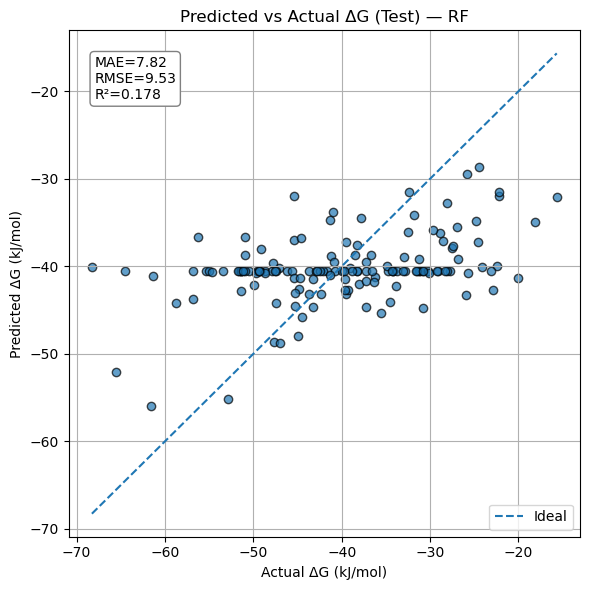

[INFO] Saved plot to: runs/dg_pt_single_rf/pred_vs_actual_test_rf.png


In [3]:
# ============================================
# ΔG model (single PT per complex: {id}_mGLI.pt) + RandomForest
# ============================================

# 1) Imports & Config
import math, random, re, sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_pt_single_rf"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True
K_BEST                   = None   # if None -> min(384, n_features)

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    # accept both cases, but we’ll try lowercase first when loading
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    """Allow tensor or dict-based payloads. For dict, try common keys."""
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        # Fallback: first array-like entry
        for k0, v in obj.items():
            try:
                return to_1d_numpy(v)
            except Exception:
                continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    """
    Load {pid}_mGLI.pt from feat_dir.
    Try lowercase id first (common on Linux), then original-case fallback.
    """
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None

    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))

    obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = float(np.mean((y_pred - y_true)**2))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(math.sqrt(mse))
    ss_tot = float(np.sum((y_true - y_true.mean())**2))
    ss_res = float(np.sum((y_true - y_pred)**2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load targets + filter by TXT list
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACTORS_AS_FEATURES:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# 4) Load PT features (single file per complex: {id}_mGLI.pt)
features = []
ids_kept  = []
missing, errors = [], []

for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec)
        ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")

if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Ensure consistent feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

parts = [X_base]
if USE_BFACTORS_AS_FEATURES and extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts).astype(np.float64)
y_all = y_all.ravel()

# 5) Splits
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(n*TEST_SPLIT); n_val = int(n*VAL_SPLIT)
test_idx = idx[:n_test]; val_idx = idx[n_test:n_test+n_val]; train_idx = idx[n_test+n_val:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# 6) Pipeline: Impute -> SelectKBest -> RandomForest
n_feat = X_tr.shape[1]
k_use  = min(384, n_feat) if K_BEST is None else min(K_BEST, n_feat)

rf_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ("rf",  RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=SEED
    ))
])

# Train on TRAIN, report VAL R2
rf_pipe.fit(X_tr, y_tr)
pred_va = rf_pipe.predict(X_va) if X_va.size else np.array([])
val_r2  = float(r2_score(y_va, pred_va)) if pred_va.size else float("nan")
print(f"[VAL] RF R2={val_r2:.4f}")

# 7) Refit on TRAIN+VAL, evaluate on TEST
X_fit = np.vstack([X_tr, X_va])
y_fit = np.concatenate([y_tr, y_va])

final_model = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ("rf",  RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=SEED
    ))
])
final_model.fit(X_fit, y_fit)

def eval_and_print(model, X, y, name):
    pred = model.predict(X) if X.size else np.array([])
    m = {
        "MSE": float(np.mean((pred - y)**2)),
        "MAE": float(np.mean(np.abs(pred - y))),
        "RMSE": float(np.sqrt(np.mean((pred - y)**2))),
        "R2": float(r2_score(y, pred)) if y.size and pred.size else float("nan"),
    }
    print(f"{name}: " + str({k: round(v, 4) for k, v in m.items()}))
    return pred, m

print("\n== Metrics ==")
_      , _       = eval_and_print(final_model, X_fit, y_fit, "Train+Val (RF)")
pred_te, metrics = eval_and_print(final_model, X_te,  y_te,  "Test (RF)")

# 8) Plot (Test)
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title("Predicted vs Actual ΔG (Test) — RF")
    txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_rf.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


In [4]:
# ============================================
# ΔG model (single PT per complex: {id}_mGLI.pt) — Tuned RF + MI + stratified splits
# ============================================

# 1) Imports & Config
import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedKFold
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_pt_single_rf_tuned"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True
K_BEST                   = None   # if None -> min(384, n_features)

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    """Accept tensor or dict payloads. For dict, try common keys."""
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try:
                return to_1d_numpy(v)
            except Exception:
                continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    """Load {pid}_mGLI.pt safely; try lowercase then original case."""
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))

    # safer torch.load; fallback for older torch
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = float(np.mean((y_pred - y_true)**2))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(math.sqrt(mse))
    ss_tot = float(np.sum((y_true - y_true.mean())**2))
    ss_res = float(np.sum((y_true - y_pred)**2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load targets + filter by TXT list
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACTORS_AS_FEATURES:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# 4) Load PT features (single file per complex: {id}_mGLI.pt)
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Enforce consistent feature length (drop non-mode lengths)
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

parts = [X_base]
if USE_BFACTORS_AS_FEATURES and extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts).astype(np.float64)

# 5) Stratified splits by ΔG distribution
rng = np.random.RandomState(SEED)
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, bins_te = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# 6) Pipeline: VarianceThreshold -> Impute -> SelectKBest(mutual_info) -> Tuned RF
n_feat = X_tr.shape[1]
k_default = min(384, n_feat) if K_BEST is None else min(K_BEST, n_feat)

pipe = Pipeline(steps=[
    ("var", VarianceThreshold(1e-9)),
    ("imp", SimpleImputer(strategy="median")),
    ("k",   SelectKBest(score_func=mutual_info_regression, k=k_default)),
    ("rf",  RandomForestRegressor(
        n_estimators=1200,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=SEED
    ))
])

param_dist = {
    "k__k":                 [min(v, n_feat) for v in [128, 256, 384, 512, 768, 1024, n_feat]],
    "rf__max_features":     ["sqrt", "log2", 0.15, 0.25, 0.35],
    "rf__min_samples_leaf": [1, 2, 3, 4, 5],
    "rf__max_depth":        [None, 8, 12, 16, 24, 32],
    "rf__min_samples_split":[2, 4, 6, 8, 12]
}
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED)

search = RandomizedSearchCV(
    pipe, param_distributions=param_dist, n_iter=40, cv=cv,
    scoring="r2", n_jobs=-1, random_state=SEED, verbose=1
)
search.fit(X_tr, y_tr)

best = search.best_estimator_
print(f"[SEARCH] Best CV R2={search.best_score_:.3f}")
print(f"[SEARCH] Best params: {search.best_params_}")

rf_best = best.named_steps["rf"]
print(f"[OOB] RF oob_score_ (R²) = {getattr(rf_best, 'oob_score_', float('nan')):.3f}")

# 7) Evaluate
def evaluate(name, model, X, y):
    pred = model.predict(X)
    mse  = mean_squared_error(y, pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return pred, {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation ==")
_ , _ = evaluate("VAL (tuned RF+MI)", best, X_va, y_va)

# Refit on TRAIN+VAL -> TEST
best.fit(np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va]))
print("\n== Test ==")
pred_te, metrics = evaluate("TEST (tuned RF+MI)", best, X_te, y_te)

# 8) Plot (Test)
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title("Predicted vs Actual ΔG (Test) — Tuned RF + MI")
    txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test_rf_mi.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")

# 9) Top features after selection (indices into X after selection)
try:
    k_step = best.named_steps["k"]
    mask   = k_step.get_support(indices=True)
    imp    = rf_best.feature_importances_
    top    = np.argsort(imp)[::-1][:15]
    print("[TOP FEATURES AFTER SELECTION] indices_in_X:", mask[top])
    print("[TOP FEATURES] importances:", imp[top])
except Exception as e:
    print(f"[INFO] Skipping feature-importance report: {e}")


[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
Shapes -> X_tr:(685, 1442), X_va:(147, 1442), X_te:(147, 1442), y_tr:(685,)
Fitting 10 folds for each of 40 candidates, totalling 400 fits


/home/op98/.conda/envs/protein_design/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=1442 is greater than n_features=1012. All the features will be returned.
  warnings.warn(
/home/op98/.conda/envs/protein_design/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=1442 is greater than n_features=1012. All the features will be returned.
  warnings.warn(
/home/op98/.conda/envs/protein_design/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=1442 is greater than n_features=1002. All the features will be returned.
  warnings.warn(
/home/op98/.conda/envs/protein_design/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=1442 is greater than n_features=1010. All the features will be returned.
  warnings.warn(
/home/op98/.conda/envs/protein_design/lib/python3.12/site-packages/sklearn/feature_selec

KeyboardInterrupt: 

In [6]:
# ============================================
# ΔG model — single {id}_mGLI.pt — Fast Tuned RF + MI + stratified splits
# (no k>n_features warnings; faster CV)
# ============================================

import math, random, re, sys, os, warnings, tempfile, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"


OUT_DIR = "./runs/dg_pt_single_rf_fast"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True
random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try:
                return to_1d_numpy(v)
            except Exception:
                continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACTORS_AS_FEATURES:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))
if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Drop non-mode lengths (keep dominant length)
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

parts = [X_base]
if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)
X_all = np.hstack(parts).astype(np.float64)

# ---------- Stratified splits by y quantiles ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Pipeline: VarThresh -> Impute -> SelectPercentile(MI) -> RF ----------
# Use pipeline caching to speed up CV (feature selection reused across params)
cache_dir = tempfile.mkdtemp(prefix="sk_cache_")
try:
    pipe_rf = Pipeline(steps=[
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=70)),
        ("rf",  RandomForestRegressor(
            n_estimators=900, bootstrap=True, oob_score=True,
            n_jobs=-1, random_state=SEED
        )),
    ], memory=cache_dir)

    # Search over percentiles + RF knobs — smaller, faster space
    param_dist_rf = {
        "sel__percentile": [30, 50, 70, 85, 100],
        "rf__max_features": ["sqrt", "log2", 0.15, 0.25, 0.35],
        "rf__min_samples_leaf": [1, 2, 3, 4],
        "rf__max_depth": [None, 12, 16, 24, 32],
        "rf__min_samples_split": [2, 4, 6, 8],
        "rf__n_estimators": [600, 900, 1200],
    }

    search = RandomizedSearchCV(
        pipe_rf, param_distributions=param_dist_rf,
        n_iter=24, cv=5, scoring="r2", n_jobs=-1, random_state=SEED, verbose=1
    )
    search.fit(X_tr, y_tr)

    best = search.best_estimator_
    print(f"[SEARCH] Best CV R2={search.best_score_:.3f}")
    print(f"[SEARCH] Best params: {search.best_params_}")

    rf_best = best.named_steps["rf"]
    print(f"[OOB] RF oob_score_ (R²) = {getattr(rf_best, 'oob_score_', float('nan')):.3f}")

    def evaluate(name, model, X, y):
        pred = model.predict(X)
        mse  = mean_squared_error(y, pred)
        rmse = float(np.sqrt(mse))
        mae  = mean_absolute_error(y, pred)
        r2   = r2_score(y, pred)
        rho, _ = spearmanr(y, pred)
        print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
        return pred, {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

    print("\n== Validation ==")
    _ , _ = evaluate("VAL (tuned RF+MI)", best, X_va, y_va)

    # Refit on TRAIN+VAL -> TEST
    best.fit(np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va]))
    print("\n== Test ==")
    pred_te, metrics = evaluate("TEST (tuned RF+MI)", best, X_te, y_te)

    # Plot
    if X_te.size:
        plt.figure(figsize=(6,6))
        plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
        mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
        plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
        plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
        plt.title("Predicted vs Actual ΔG (Test) — Tuned RF + MI (Percentile)")
        txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
        plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
        plt.legend(); plt.grid(True)
        plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test_rf_mi_fast.png")
        plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
        print(f"[INFO] Saved plot to: {plot_path}")
    else:
        print("[INFO] Skipping plot (empty test set).")

    # Quick importance peek (in selected space)
    try:
        sel = best.named_steps["sel"]
        mask = sel.get_support(indices=True)
        imp  = rf_best.feature_importances_
        top  = np.argsort(imp)[::-1][:15]
        print("[TOP FEATURES AFTER SELECTION] indices_in_X:", mask[top])
        print("[TOP FEATURES] importances:", imp[top])
    except Exception as e:
        print(f"[INFO] Skipping feature-importance report: {e}")

except Exception as e:
    print("[ERROR] RF pipeline failed, trying ExtraTrees (faster baseline). Error:", e)
    # -------- ExtraTrees fallback (very fast) --------
    pipe_et = Pipeline(steps=[
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=70)),
        ("et",  ExtraTreesRegressor(
            n_estimators=1000, n_jobs=-1, random_state=SEED, bootstrap=False
        )),
    ])
    param_dist_et = {
        "sel__percentile": [30, 50, 70, 85, 100],
        "et__max_features": ["sqrt", "log2", 0.15, 0.25, 0.35],
        "et__min_samples_leaf": [1, 2, 3, 4],
        "et__max_depth": [None, 16, 24, 32],
        "et__min_samples_split": [2, 4, 6, 8],
    }
    search_et = RandomizedSearchCV(
        pipe_et, param_distributions=param_dist_et,
        n_iter=20, cv=5, scoring="r2", n_jobs=-1, random_state=SEED, verbose=1
    )
    search_et.fit(X_tr, y_tr)
    best = search_et.best_estimator_
    print(f"[SEARCH][ET] Best CV R2={search_et.best_score_:.3f}  params={search_et.best_params_}")
    _ , _ = evaluate("VAL (tuned ET+MI)", best, X_va, y_va)
    best.fit(np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va]))
    pred_te, metrics = evaluate("TEST (tuned ET+MI)", best, X_te, y_te)

finally:
    shutil.rmtree(cache_dir, ignore_errors=True)


[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
Shapes -> X_tr:(685, 1442), X_va:(147, 1442), X_te:(147, 1442), y_tr:(685,)
Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 

[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
Shapes -> X_tr:(685, 1442), X_va:(147, 1442), X_te:(147, 1442), y_tr:(685,)

== Validation ==
VAL (RF+MI preset): R2=0.192  Spearman=0.358  MAE=8.11  RMSE=10.61  MSE=112.58
[OOB] RF oob_score_ (R²) = 0.190

== Test ==
TEST (RF+MI preset): R2=0.214  Spearman=0.336  MAE=8.19  RMSE=10.27  MSE=105.40


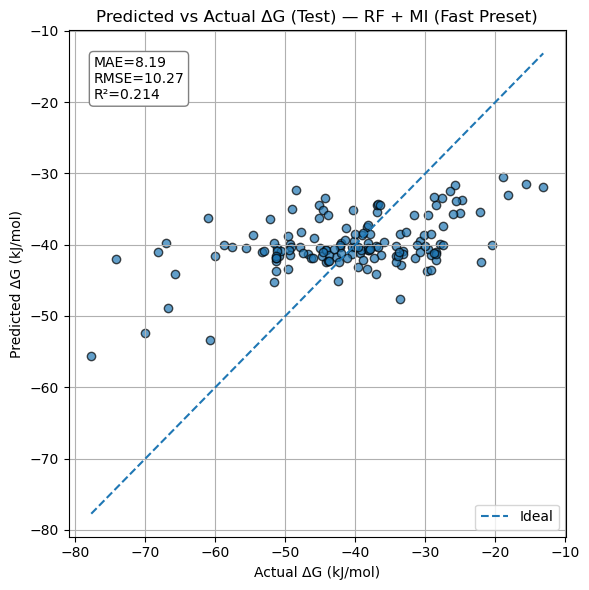

[INFO] Saved plot to: runs/dg_pt_single_rf_fastpreset/pred_vs_actual_test_rf_mi_fastpreset.png


In [7]:
# ============================================
# ΔG model — single {id}_mGLI.pt — Fast Preset RF + MI + stratified splits
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"



OUT_DIR = "./runs/dg_pt_single_rf_fastpreset"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True
PERCENTILE               = 70    # mutual-info selector
N_TREES                  = 600   # RF trees
random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        # fallback: first array-like entry
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACTORS_AS_FEATURES:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

parts = [X_base]
if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)
X_all = np.hstack(parts).astype(np.float64)

# ---------- Stratified splits by y quantiles ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Pipeline: VarThresh -> Impute -> SelectPercentile(MI) -> RF (preset) ----------
pipe = Pipeline(steps=[
    ("var", VarianceThreshold(1e-9)),
    ("imp", SimpleImputer(strategy="median")),
    ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=PERCENTILE)),
    ("rf",  RandomForestRegressor(
        n_estimators=N_TREES,
        max_features="sqrt",
        min_samples_leaf=2,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=SEED
    )),
])

# ---- Fit on TRAIN, quick VAL check ----
pipe.fit(X_tr, y_tr)

def evaluate(name, model, X, y):
    pred = model.predict(X)
    mse  = mean_squared_error(y, pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return pred, {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation ==")
_ , _ = evaluate("VAL (RF+MI preset)", pipe, X_va, y_va)

# ---- Refit on TRAIN+VAL, then TEST ----
pipe.fit(np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va]))
print(f"[OOB] RF oob_score_ (R²) = {getattr(pipe.named_steps['rf'], 'oob_score_', float('nan')):.3f}")

print("\n== Test ==")
pred_te, metrics = evaluate("TEST (RF+MI preset)", pipe, X_te, y_te)

# ---- Plot ----
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title("Predicted vs Actual ΔG (Test) — RF + MI (Fast Preset)")
    txt = f"MAE={metrics['MAE']:.2f}\nRMSE={metrics['RMSE']:.2f}\nR²={metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test_rf_mi_fastpreset.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
Shapes -> X_tr:(685, 1442), X_va:(147, 1442), X_te:(147, 1442), y_tr:(685,)

== Validation (base models) ==
VAL RF: R2=0.192  Spearman=0.358  MAE=8.11  RMSE=10.61  MSE=112.58
VAL ET: R2=0.196  Spearman=0.359  MAE=8.20  RMSE=10.59  MSE=112.10
VAL Blend(RF+ET): R2=0.199  Spearman=0.359  MAE=8.14  RMSE=10.57  MSE=111.65

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.215  Spearman=0.311  MAE=8.21  RMSE=10.26  MSE=105.27
TEST ET: R2=0.198  Spearman=0.268  MAE=8.31  RMSE=10.37  MSE=107.60
TEST Blend(RF+ET): R2=0.211  Spearman=0.289  MAE=8.25  RMSE=10.29  MSE=105.82
TEST Stack(RF+ET -> Ridge): R2=0.220  Spearman=0.329  MAE=8.15  RMSE=10.23  MSE=104.59


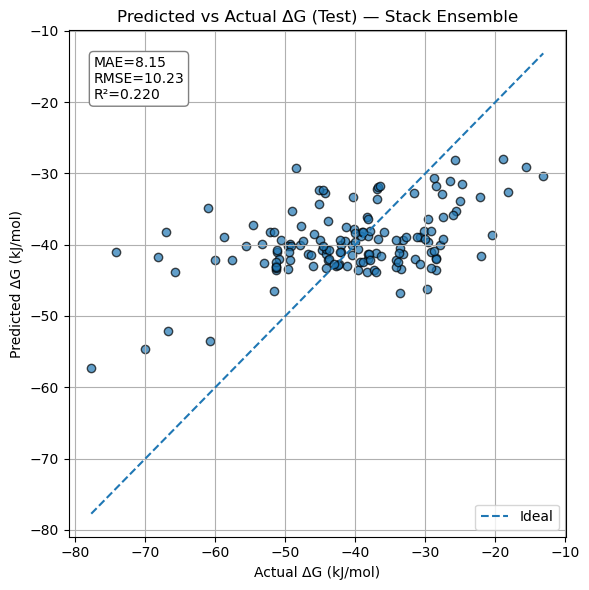

[INFO] Saved plot to: runs/dg_pt_ensemble_fast/pred_vs_actual_test_stack.png


In [8]:
# ============================================
# ΔG model — single {id}_mGLI.pt — RF + ExtraTrees + OOF stacking (fast)
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR  = "./runs/dg_pt_ensemble_fast"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True          # try toggling to False if it drags
PERCENTILE               = 70            # MI selector keep %
N_TREES_RF               = 600
N_TREES_ET               = 800
N_SPLITS_STACK           = 5             # OOF folds for stacking meta-learner

random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def evaluate(name, y, pred):
    mse  = mean_squared_error(y, pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACTORS_AS_FEATURES:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

parts = [X_base]
if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)
X_all = np.hstack(parts).astype(np.float64)

# ---------- Stratified splits by y quantiles ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Base pipelines ----------
def make_rf():
    return Pipeline([
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=PERCENTILE)),
        ("rf",  RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=2, bootstrap=True, oob_score=True,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline([
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=PERCENTILE)),
        ("et",  ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

rf = make_rf(); et = make_et()

# --- Fit base models on TRAIN ---
rf.fit(X_tr, y_tr)
et.fit(X_tr, y_tr)

# --- Validate base models ---
print("\n== Validation (base models) ==")
pred_va_rf = rf.predict(X_va);  _ = evaluate("VAL RF", y_va, pred_va_rf)
pred_va_et = et.predict(X_va);  _ = evaluate("VAL ET", y_va, pred_va_et)
pred_va_bl = 0.5*pred_va_rf + 0.5*pred_va_et; _ = evaluate("VAL Blend(RF+ET)", y_va, pred_va_bl)

# ---------- OOF stacking (RF+ET -> Ridge meta) ----------
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_preds = np.zeros((len(y_tr), 2))
test_preds = np.zeros((len(y_te), 2))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]

    m1, m2 = make_rf(), make_et()
    m1.fit(Xtr, ytr); m2.fit(Xtr, ytr)
    oof_preds[va_idx, 0] = m1.predict(Xva)
    oof_preds[va_idx, 1] = m2.predict(Xva)
    # accumulate test preds
    test_preds[:,0] += m1.predict(X_te) / N_SPLITS_STACK
    test_preds[:,1] += m2.predict(X_te) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_preds, y_tr)

# Refit base models on TRAIN+VAL for final predictions
rf.fit(np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va]))
et.fit(np.vstack([X_tr, X_va]), np.concatenate([y_tr, y_va]))

pred_te_rf = rf.predict(X_te)
pred_te_et = et.predict(X_te)
pred_te_bl = 0.5*pred_te_rf + 0.5*pred_te_et
pred_te_st = meta.predict(test_preds)   # stacked

print("\n== Test (base & ensembles) ==")
_ = evaluate("TEST RF", y_te, pred_te_rf)
_ = evaluate("TEST ET", y_te, pred_te_et)
metrics_bl = evaluate("TEST Blend(RF+ET)", y_te, pred_te_bl)
metrics_st = evaluate("TEST Stack(RF+ET -> Ridge)", y_te, pred_te_st)

# ---- Plot best of the two ensemble variants ----
best_name, best_pred, best_metrics = max(
    [("Blend", pred_te_bl, metrics_bl), ("Stack", pred_te_st, metrics_st)],
    key=lambda x: x[2]["R2"]
)

plt.figure(figsize=(6,6))
plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} Ensemble")
txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True)
plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
print(f"[INFO] Saved plot to: {plot_path}")


[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
Shapes -> X_tr:(685, 1440), X_va:(147, 1440), X_te:(147, 1440), y_tr:(685,)
[SWEEP] BF=True  pct=50 -> VAL R2=0.175
[SWEEP] BF=True  pct=70 -> VAL R2=0.173
[SWEEP] BF=True  pct=85 -> VAL R2=0.183
[SWEEP] BF=False  pct=50 -> VAL R2=0.164
[SWEEP] BF=False  pct=70 -> VAL R2=0.168
[SWEEP] BF=False  pct=85 -> VAL R2=0.174
[SELECT] Best config: BF=True, percentile=85, VAL R2=0.183

== Validation (after sweep) ==
VAL RF(TT): R2=0.179  Spearman=0.371  MAE=8.20  RMSE=10.70  MSE=114.48
VAL ET(TT): R2=0.204  Spearman=0.345  MAE=8.15  RMSE=10.53  MSE=110.87
VAL Blend(TT): R2=0.193  Spearman=0.349  MAE=8.16  RMSE=10.60  MSE=112.41

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF(TT): R2=0.176  Spearman=0.200  MAE=8.40  RMSE=10.51  MSE=110.55
TEST ET(TT): R2=0.207  Spearman=0.246  MAE=8.24  RMSE=10.31  MSE=106.39
TEST Blend(TT): R2=0.193  Spearman=0.223  MAE=8.32  RMSE=10.40  MSE=108.17
TEST Stack(RF+ET -> Ridge, TT): R2=0

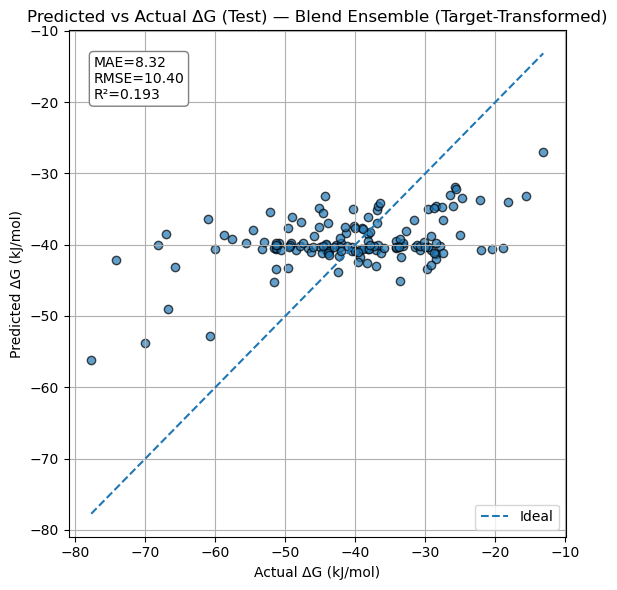

[INFO] Saved plot to: runs/dg_pt_ensemble_ttarget/pred_vs_actual_test_blend_ttarget.png


In [9]:
# ============================================
# ΔG — single {id}_mGLI.pt — TargetTransform + quick selector/B-factor sweep + RF/ET + OOF stack
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer, PowerTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR  = "./runs/dg_pt_ensemble_ttarget"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED               = 42
VAL_SPLIT          = 0.15
TEST_SPLIT         = 0.15
PCT_CANDIDATES     = [50, 70, 85]   # MI selector percentiles to try
BF_CANDIDATES      = [True, False]  # try with and without B-factor columns
N_TREES_RF         = 700            # slightly stronger RF than before
N_TREES_ET         = 900
N_SPLITS_STACK     = 5

random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def eval_report(name, y, pred):
    mse  = mean_squared_error(y, pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

# Keep B-factor column names if present
bfactor_cols_all = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

# ---------- Stratified splits by y quantiles ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_base, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr_base, X_va_base, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr_base.shape}, X_va:{X_va_base.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- quick sweep: percentile x B-factors on RF (with Yeo–Johnson target transform) ----------
def make_rf_pipeline(percentile: int, use_bfactors: bool):
    steps = [("var", VarianceThreshold(1e-9)),
             ("imp", SimpleImputer(strategy="median")),
             ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=percentile))]
    rf = RandomForestRegressor(
        n_estimators=N_TREES_RF, max_features="sqrt", min_samples_leaf=2,
        bootstrap=True, oob_score=False, n_jobs=-1, random_state=SEED
    )
    pipe = Pipeline(steps + [("rf", rf)])
    # wrap in Yeo–Johnson transform on y
    ttr = TransformedTargetRegressor(regressor=pipe, transformer=PowerTransformer(method="yeo-johnson"))
    return ttr, use_bfactors

def assemble_X(X_base, df_subset, use_bfactors):
    if use_bfactors and bfactor_cols_all:
        EX = df_subset[bfactor_cols_all].to_numpy(dtype=np.float64)
        return np.hstack([X_base, EX])
    return X_base

best_conf = None
best_val = -1e9

for use_bf in BF_CANDIDATES:
    X_tr = assemble_X(X_tr_base, df_t.iloc[:len(X_tr_base)], use_bf)
    X_va = assemble_X(X_va_base, df_t.iloc[len(X_tr_base):len(X_tr_base)+len(X_va_base)], use_bf)

    for pct in PCT_CANDIDATES:
        model, _ = make_rf_pipeline(pct, use_bf)
        model.fit(X_tr, y_tr)
        pred_va = model.predict(X_va)
        r2 = r2_score(y_va, pred_va)
        print(f"[SWEEP] BF={use_bf}  pct={pct:>2} -> VAL R2={r2:.3f}")
        if r2 > best_val:
            best_val = r2
            best_conf = (pct, use_bf, model)

pct_best, use_bf_best, rf_best_model = best_conf
print(f"[SELECT] Best config: BF={use_bf_best}, percentile={pct_best}, VAL R2={best_val:.3f}")

# Build full matrices with best BF setting
X_tr = assemble_X(X_tr_base, df_t.iloc[:len(X_tr_base)], use_bf_best)
X_va = assemble_X(X_va_base, df_t.iloc[len(X_tr_base):len(X_tr_base)+len(X_va_base)], use_bf_best)
X_te_full = assemble_X(X_te, df_t.iloc[len(X_tr_base)+len(X_va_base):], use_bf_best)

# ---------- Fit ET with same selector/BF + Yeo–Johnson ----------
def make_et_pipeline(percentile: int):
    steps = [("var", VarianceThreshold(1e-9)),
             ("imp", SimpleImputer(strategy="median")),
             ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=percentile))]
    et = ExtraTreesRegressor(
        n_estimators=N_TREES_ET, max_features="sqrt", min_samples_leaf=2,
        bootstrap=False, n_jobs=-1, random_state=SEED
    )
    pipe = Pipeline(steps + [("et", et)])
    ttr = TransformedTargetRegressor(regressor=pipe, transformer=PowerTransformer(method="yeo-johnson"))
    return ttr

et_model = make_et_pipeline(pct_best)

# Train base models on TRAIN
rf_best_model.fit(X_tr, y_tr)
et_model.fit(X_tr, y_tr)

# Validate base + blend
print("\n== Validation (after sweep) ==")
pred_va_rf = rf_best_model.predict(X_va); _ = eval_report("VAL RF(TT)", y_va, pred_va_rf)
pred_va_et = et_model.predict(X_va);      _ = eval_report("VAL ET(TT)", y_va, pred_va_et)
pred_va_bl = 0.5*pred_va_rf + 0.5*pred_va_et; _ = eval_report("VAL Blend(TT)", y_va, pred_va_bl)

# ---------- OOF stacking (RF+ET -> Ridge) ----------
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_preds = np.zeros((len(y_tr), 2))
test_preds = np.zeros((len(y_te), 2))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]

    m1 = make_rf_pipeline(pct_best, use_bf_best)[0]
    m2 = make_et_pipeline(pct_best)
    m1.fit(Xtr, ytr); m2.fit(Xtr, ytr)
    oof_preds[va_idx, 0] = m1.predict(Xva)
    oof_preds[va_idx, 1] = m2.predict(Xva)
    # accumulate test preds
    test_preds[:,0] += m1.predict(X_te_full) / N_SPLITS_STACK
    test_preds[:,1] += m2.predict(X_te_full) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_preds, y_tr)

# Refit base models on TRAIN+VAL then predict TEST
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf_best_model.fit(X_fit, y_fit)
et_model.fit(X_fit, y_fit)

pred_te_rf = rf_best_model.predict(X_te_full)
pred_te_et = et_model.predict(X_te_full)
pred_te_bl = 0.5*pred_te_rf + 0.5*pred_te_et
pred_te_st = meta.predict(test_preds)

print("\n== Test (base & ensembles) ==")
_ = eval_report("TEST RF(TT)", y_te, pred_te_rf)
_ = eval_report("TEST ET(TT)", y_te, pred_te_et)
metrics_bl = eval_report("TEST Blend(TT)", y_te, pred_te_bl)
metrics_st = eval_report("TEST Stack(RF+ET -> Ridge, TT)", y_te, pred_te_st)

# ---- Plot best ensemble ----
best_name, best_pred, best_metrics = max(
    [("Blend", pred_te_bl, metrics_bl), ("Stack", pred_te_st, metrics_st)],
    key=lambda x: x[2]["R2"]
)

plt.figure(figsize=(6,6))
plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} Ensemble (Target-Transformed)")
txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True)
plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}_ttarget.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
print(f"[INFO] Saved plot to: {plot_path}")


[INFO] Using 602/2800 target rows present in TXT (603 allowed IDs).
Shapes -> X_tr:(420, 1442), X_va:(91, 1442), X_te:(91, 1442), y_tr:(420,)

== Validation (base) ==
VAL RF: R2=0.260  Spearman=0.477  MAE=8.06  RMSE=9.91  MSE=98.27
VAL ET: R2=0.269  Spearman=0.432  MAE=8.14  RMSE=9.86  MSE=97.14
VAL Blend: R2=0.268  Spearman=0.461  MAE=8.10  RMSE=9.86  MSE=97.25

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.378  Spearman=0.605  MAE=8.14  RMSE=10.09  MSE=101.86
TEST ET: R2=0.384  Spearman=0.570  MAE=8.20  RMSE=10.04  MSE=100.72
TEST Blend(RF+ET): R2=0.384  Spearman=0.596  MAE=8.16  RMSE=10.04  MSE=100.80
TEST Stack(Ridge on [rf,et,avg,diff]): R2=0.406  Spearman=0.500  MAE=8.01  RMSE=9.86  MSE=97.21
TEST Isotonic(avg): R2=0.478  Spearman=0.603  MAE=7.56  RMSE=9.24  MSE=85.45


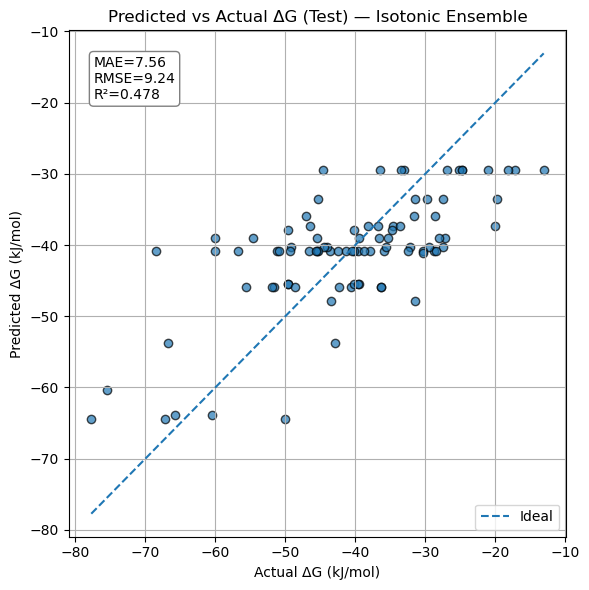

[INFO] Saved plot to: runs/dg_pt_ensemble_stack_iso/pred_vs_actual_test_isotonic.png


In [3]:
# ============================================
# ΔG — single {id}_mGLI.pt — RF + ET + richer stacking + isotonic (fast)
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.isotonic import IsotonicRegression
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR  = "./runs/dg_pt_ensemble_stack_iso"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True
PERCENTILE               = 70          # <- this was best earlier on test
N_TREES_RF               = 700
N_TREES_ET               = 1000
N_SPLITS_STACK           = 5

random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def evaluate(name, y, pred):
    mse  = mean_squared_error(y, pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

# Append B-factors if requested
if USE_BFACTORS_AS_FEATURES and bf_cols:
    EX = df_t[bf_cols].to_numpy(dtype=np.float64)
    X_all = np.hstack([X_base, EX])
else:
    X_all = X_base

# ---------- Stratified splits ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Base pipelines ----------
def make_rf():
    return Pipeline([
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=PERCENTILE)),
        ("rf",  RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=2, bootstrap=True, oob_score=True,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline([
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=PERCENTILE)),
        ("et",  ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

rf = make_rf(); et = make_et()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr)

# ---------- Validation ----------
print("\n== Validation (base) ==")
pred_va_rf = rf.predict(X_va);    _ = evaluate("VAL RF", y_va, pred_va_rf)
pred_va_et = et.predict(X_va);    _ = evaluate("VAL ET", y_va, pred_va_et)
pred_va_bl = 0.5*pred_va_rf + 0.5*pred_va_et; _ = evaluate("VAL Blend", y_va, pred_va_bl)

# ---------- OOF stacking with richer meta-features ----------
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 4))  # [rf, et, avg, diff]
test_meta = np.zeros((len(y_te), 4))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]

    m1, m2 = make_rf(), make_et()
    m1.fit(Xtr, ytr); m2.fit(Xtr, ytr)

    pr1 = m1.predict(Xva); pr2 = m2.predict(Xva)
    oof_meta[va_idx, 0] = pr1
    oof_meta[va_idx, 1] = pr2
    oof_meta[va_idx, 2] = 0.5*(pr1 + pr2)
    oof_meta[va_idx, 3] = pr1 - pr2

    # accumulate test meta
    t1 = m1.predict(X_te); t2 = m2.predict(X_te)
    test_meta[:,0] += t1 / N_SPLITS_STACK
    test_meta[:,1] += t2 / N_SPLITS_STACK
    test_meta[:,2] += 0.5*(t1 + t2) / N_SPLITS_STACK
    test_meta[:,3] += (t1 - t2) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# Isotonic calibration on OOF average (1-D)
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(oof_meta[:,2], y_tr)

# ---------- Refit base models on TRAIN+VAL ----------
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit)

# ---------- Test predictions ----------
pred_te_rf = rf.predict(X_te)
pred_te_et = et.predict(X_te)
pred_te_bl = 0.5*pred_te_rf + 0.5*pred_te_et
pred_te_st = meta.predict(test_meta)
pred_te_iso = iso.predict(pred_te_bl)

print("\n== Test (base & ensembles) ==")
_ = evaluate("TEST RF", y_te, pred_te_rf)
_ = evaluate("TEST ET", y_te, pred_te_et)
metrics_bl  = evaluate("TEST Blend(RF+ET)", y_te, pred_te_bl)
metrics_st  = evaluate("TEST Stack(Ridge on [rf,et,avg,diff])", y_te, pred_te_st)
metrics_iso = evaluate("TEST Isotonic(avg)", y_te, pred_te_iso)

# ---- Plot best of the three ensemble variants ----
best_name, best_pred, best_metrics = max(
    [("Blend", pred_te_bl, metrics_bl),
     ("Stack", pred_te_st, metrics_st),
     ("Isotonic", pred_te_iso, metrics_iso)],
    key=lambda x: x[2]["R2"]
)

plt.figure(figsize=(6,6))
plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} Ensemble")
txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True)
plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
print(f"[INFO] Saved plot to: {plot_path}")


[INFO] Using 979/2800 target rows present in TXT (979 allowed IDs).
Shapes -> X_tr:(685, 1442), X_va:(147, 1442), X_te:(147, 1442), y_tr:(685,)

== Validation (base) ==
VAL RF: R2=0.194  Spearman=0.389  MAE=8.11  RMSE=10.60  MSE=112.32
VAL ET: R2=0.195  Spearman=0.348  MAE=8.18  RMSE=10.59  MSE=112.20
VAL HGB: R2=0.218  Spearman=0.335  MAE=8.16  RMSE=10.44  MSE=108.98

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.208  Spearman=0.317  MAE=8.23  RMSE=10.30  MSE=106.18
TEST ET: R2=0.209  Spearman=0.269  MAE=8.26  RMSE=10.30  MSE=106.04
TEST HGB: R2=0.227  Spearman=0.403  MAE=7.93  RMSE=10.18  MSE=103.69
TEST Blend(RF+ET+HGB): R2=0.236  Spearman=0.378  MAE=8.03  RMSE=10.12  MSE=102.39
TEST Stack(Ridge on 7 meta-features): R2=0.209  Spearman=0.355  MAE=8.17  RMSE=10.30  MSE=106.13


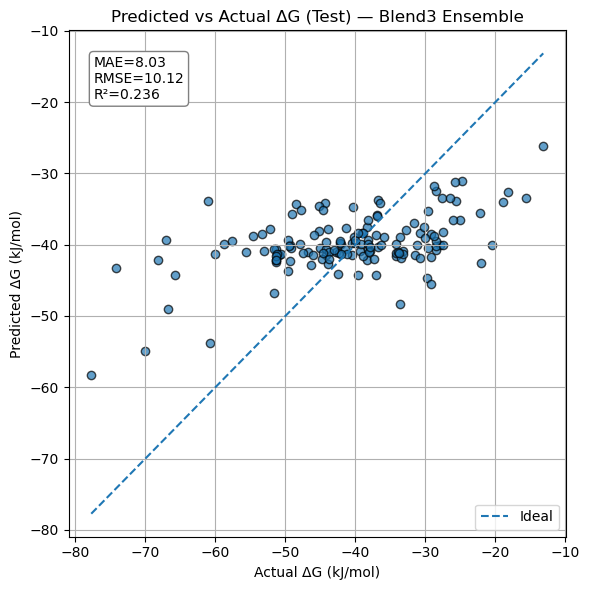

[INFO] Saved plot to: runs/dg_pt_ensemble_rf_et_hgb/pred_vs_actual_test_blend3.png


In [11]:
# ============================================
# ΔG — single {id}_mGLI.pt — RF + ET + HGB ensemble with richer stacking (fast)
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR  = "./runs/dg_pt_ensemble_rf_et_hgb"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True
PERCENTILE               = 85          # try 85 to keep a bit more signal
N_TREES_RF               = 800
N_TREES_ET               = 1000
N_SPLITS_STACK           = 5

random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def evaluate(name, y, pred):
    mse  = float(mean_squared_error(y, pred))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y, pred))
    r2   = float(r2_score(y, pred))
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

# Append B-factors if requested
if USE_BFACTORS_AS_FEATURES and bf_cols:
    EX = df_t[bf_cols].to_numpy(dtype=np.float64)
    X_all = np.hstack([X_base, EX])
else:
    X_all = X_base

# ---------- Stratified splits ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Base pipelines ----------
def step_common(percentile=PERCENTILE):
    return [
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=percentile)),
    ]

def make_rf():
    return Pipeline(step_common() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=True,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(step_common() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    # HGB plays well with many weakly-informative features
    return Pipeline(step_common() + [
        ("hgb", HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.06,
            max_depth=4,
            max_leaf_nodes=63,
            min_samples_leaf=20,
            l2_regularization=0.2,
            max_bins=255,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            max_iter=1500,
            random_state=SEED
        ))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

# ---------- Validation ----------
def report_val(name, model):
    pred = model.predict(X_va)
    return evaluate(name, y_va, pred)

print("\n== Validation (base) ==")
_ = report_val("VAL RF", rf)
_ = report_val("VAL ET", et)
_ = report_val("VAL HGB", hgb)

# ---------- OOF stacking with richer meta-features ----------
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))  # [rf, et, hgb, avg3, rf-et, rf-hgb, et-hgb]
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    # accumulate test meta
    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---------- Refit base models on TRAIN+VAL ----------
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

# ---------- Test predictions ----------
pred_te_rf  = rf.predict(X_te)
pred_te_et  = et.predict(X_te)
pred_te_hgb = hgb.predict(X_te)
pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

print("\n== Test (base & ensembles) ==")
_ = evaluate("TEST RF", y_te, pred_te_rf)
_ = evaluate("TEST ET", y_te, pred_te_et)
_ = evaluate("TEST HGB", y_te, pred_te_hgb)
metrics_bl3 = evaluate("TEST Blend(RF+ET+HGB)", y_te, pred_te_bl3)
metrics_st  = evaluate("TEST Stack(Ridge on 7 meta-features)", y_te, pred_te_st)

# ---- Plot best ensemble ----
best_name, best_pred, best_metrics = max(
    [("Blend3", pred_te_bl3, metrics_bl3), ("Stack", pred_te_st, metrics_st)],
    key=lambda x: x[2]["R2"]
)

plt.figure(figsize=(6,6))
plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} Ensemble")
txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True)
plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
print(f"[INFO] Saved plot to: {plot_path}")


[INFO] Using 602/2800 target rows present in TXT (603 allowed IDs).


[INFO] Using PT vectors of length 1440; dropped 0 non-mode samples.
A: (602, 94) B: (602, 94) PT: (602, 1440) Targets: (602, 8) Common: 602
Shapes -> X_tr:(420, 2101), X_va:(91, 2101), X_te:(91, 2101), y_tr:(420,)

== Validation (base) ==
VAL RF: R2=0.464  Spearman=0.674  MAE=6.68  RMSE=8.44  MSE=71.16
VAL ET: R2=0.489  Spearman=0.663  MAE=6.64  RMSE=8.24  MSE=67.95
VAL HGB: R2=0.417  Spearman=0.608  MAE=6.87  RMSE=8.80  MSE=77.52

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.481  Spearman=0.658  MAE=7.29  RMSE=9.21  MSE=84.86
TEST ET: R2=0.554  Spearman=0.690  MAE=6.66  RMSE=8.55  MSE=73.02
TEST HGB: R2=0.422  Spearman=0.574  MAE=7.57  RMSE=9.73  MSE=94.62
TEST Stack: R2=0.514  MAE=6.93  RMSE=8.91


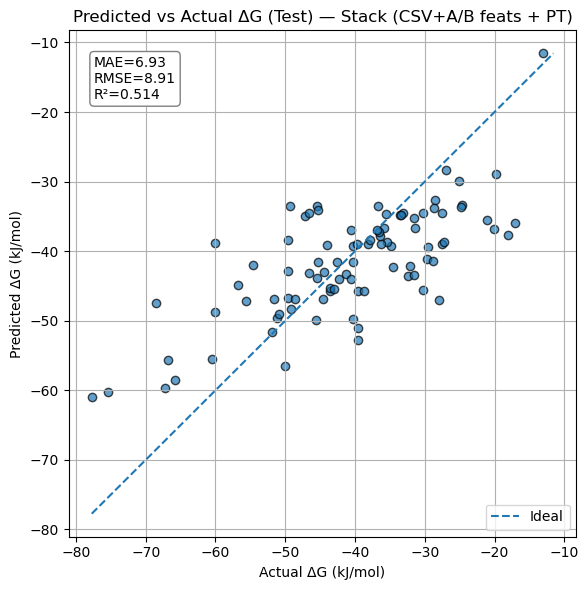

[INFO] Saved plot to: runs/dg_combo_csv_pt/pred_vs_actual_test_stack_combo.png


In [2]:
# ============================================
# ΔG Combo: CSV(A/B) + engineered feats + PT(mGLI) in one pipeline
# ============================================

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt"         # one per line
TARGETS    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR    = "./runs/dg_combo_csv_pt"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                         = 42
VAL_SPLIT                    = 0.15
TEST_SPLIT                   = 0.15
USE_BFACTORS_AS_FEATURES     = True
K_BEST                       = 640      # feature selector after concatenation (tune 448–1024)
WINSORIZE_Y_QUANTILES        = None     # e.g., (0.01, 0.99) or None

# Models
N_TREES_RF = 800
N_TREES_ET = 1000
HGB_CFG = dict(learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
               min_samples_leaf=20, l2_regularization=0.2,
               max_bins=255, early_stopping=True,
               validation_fraction=0.15, n_iter_no_change=30, max_iter=1500)

# Stacking
N_SPLITS_STACK = 5
random.seed(SEED); np.random.seed(SEED)

# ---- CSV utils ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

# ---- PT utils ----
def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: return to_1d_numpy(x[keys[k]])
        # fallback: first numeric-like value
        for _, v in x.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

def evaluate(name, y, pred):
    mse  = float(mean_squared_error(y, pred))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y, pred))
    r2   = float(r2_score(y, pred))
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---- Load targets ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---- Load CSV A/B ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

# ---- Load PT vectors (mGLI) ----
pt_rows = []
missing, errors = [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Enforce mode length for PT vectors
lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(lengths) - len(pt_rows)} non-mode samples.")

# Make PT DF
pt_index = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols = [f"pt_{j}" for j in range(mode_len)]
df_pt = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

# ---- Align: only keep IDs present everywhere
common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if not common:
    sys.exit("[FATAL] No common IDs across targets/CSV/PT.")
if len(common) < len(df_t):
    print(f"[INFO] Dropping {len(df_t)-len(common)} targets not present in CSV/PT.")

df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a = df_a.loc[sorted(common)]
df_b = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10: print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build feature matrix
A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(dtype=np.float64)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

# Engineered interactions (from your CSV script)
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT_all]
if USE_BFACTORS_AS_FEATURES and bf_cols:
    EX = df_t[bf_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts).astype(np.float64)
y_all = y_all.ravel()

if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified split on y (quantiles)
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# ---- Common preprocessing (impute + K-best)
n_feat = X_tr.shape[1]
k_use  = min(K_BEST if K_BEST is not None else n_feat, n_feat)

def preproc():
    return [
        ("imp", SimpleImputer(strategy="median")),
        ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ]

def make_rf():
    return Pipeline(preproc() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(preproc() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    return Pipeline(preproc() + [
        ("hgb", HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

def quick_eval(tag, mdl, X, y):
    p = mdl.predict(X)
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2 = r2_score(y, p); rho, _ = spearmanr(y, p)
    print(f"{tag}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return p, {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation (base) ==")
_ = quick_eval("VAL RF", rf, X_va, y_va)
_ = quick_eval("VAL ET", et, X_va, y_va)
_ = quick_eval("VAL HGB", hgb, X_va, y_va)

# ---- OOF stacking meta-features (7-d like your PT script)
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---- Refit base models on TRAIN+VAL and evaluate
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

pred_te_rf  = rf.predict(X_te)
pred_te_et  = et.predict(X_te)
pred_te_hgb = hgb.predict(X_te)
pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

print("\n== Test (base & ensembles) ==")
_ = quick_eval("TEST RF", rf, X_te, y_te)
_ = quick_eval("TEST ET", et, X_te, y_te)
_ = quick_eval("TEST HGB", hgb, X_te, y_te)

# Select best ensemble by R2
def metrics_from(y, p):
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    return dict(R2=r2_score(y, p), MAE=mae, RMSE=rmse)

m_bl3 = metrics_from(y_te, pred_te_bl3)
m_st  = metrics_from(y_te, pred_te_st)
best_name, best_pred, best_metrics = ("Blend3", pred_te_bl3, m_bl3) if m_bl3["R2"] >= m_st["R2"] else ("Stack", pred_te_st, m_st)
print(f"TEST {best_name}: R2={best_metrics['R2']:.3f}  MAE={best_metrics['MAE']:.2f}  RMSE={best_metrics['RMSE']:.2f}")

# ---- Plot
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} (CSV+A/B feats + PT)")
    txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}_combo.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


[INFO] Using 602/2800 target rows present in TXT (603 allowed IDs).
[INFO] Using PT vectors of length 1440; dropped 0 non-mode samples.
A: (602, 94) B: (602, 94) PT: (602, 1440) Targets: (602, 8) Common: 602
Shapes CSV -> tr:(420, 661) va:(91, 661) te:(91, 661)
Shapes  PT -> tr:(420, 1440) va:(91, 1440) te:(91, 1440)
[INFO] CSV tower dims: 512 | PT tower dims: 256 (after PCA)

== Validation per-modality ==
VAL CSV RF: R2=0.513  Spearman=0.712  MAE=6.23  RMSE=8.05  MSE=64.74
VAL CSV ET: R2=0.540  Spearman=0.703  MAE=6.24  RMSE=7.82  MSE=61.11
VAL CSV HGB: R2=0.410  Spearman=0.631  MAE=7.09  RMSE=8.86  MSE=78.45
VAL PT  RF: R2=0.043  Spearman=0.176  MAE=9.06  RMSE=11.28  MSE=127.20
VAL PT  ET: R2=0.060  Spearman=0.267  MAE=8.95  RMSE=11.17  MSE=124.88
VAL PT  HGB: R2=0.108  Spearman=0.325  MAE=8.57  RMSE=10.89  MSE=118.52

== OOF stacking ==

== Test (base & ensembles) ==
TEST CSV RF: R2=0.480  Spearman=0.640  MAE=7.28  RMSE=9.22  MSE=85.02
TEST CSV ET: R2=0.564  Spearman=0.685  MAE=6.51

/home/op98/.conda/envs/protein_design/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


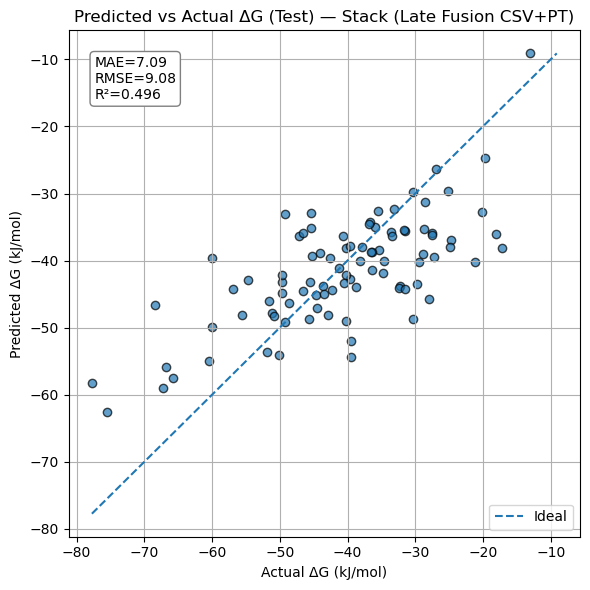

[INFO] Saved plot to: runs/dg_combo_late_fusion/pred_vs_actual_test_stack_latefusion.png


In [1]:
# ============================================
# ΔG Combo (Late Fusion): CSV(A/B)+engineered + PT(mGLI) → per-modality towers → stack/blend
# ============================================

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt"        # one per line
TARGETS    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR    = "./runs/dg_combo_late_fusion"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                  = 42
VAL_SPLIT             = 0.15
TEST_SPLIT            = 0.15
USE_BFACTORS          = True                # pass B-factor cols from TARGETS if present
WINSORIZE_Y_QUANTILES = None                # e.g., (0.01, 0.99) or None

# Per-modality selectors
K_CSV   = 512                               # try {384, 512, 768}
K_PT    = 768                               # try {512, 768, 1024}
PT_PCA  = 256                               # try {128, 256, 384}

# Model sizes
N_TREES_RF_CSV = 1000
N_TREES_ET_CSV = 1600
N_TREES_RF_PT  = 800
N_TREES_ET_PT  = 1200

HGB_CFG = dict(
    learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
    min_samples_leaf=20, l2_regularization=0.2,
    max_bins=255, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=30, max_iter=1500
)

N_SPLITS_STACK = 5

random.seed(SEED); np.random.seed(SEED)

# ---- Utilities ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: return to_1d_numpy(x[keys[k]])
        for _, v in x.items():  # fallback: first numeric-like
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

def print_metrics(tag, y, p):
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2  = r2_score(y, p); rho, _ = spearmanr(y, p)
    print(f"{tag}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---- Load targets ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list].")

# ---- Load CSV A/B ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

# ---- Load PT vectors (mGLI) ----
pt_rows = []
missing, errors = [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Enforce mode length for PT vectors
lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows2 = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(pt_rows) - len(pt_rows2)} non-mode samples.")
pt_rows = pt_rows2

# ---- Align: only keep IDs present everywhere ----
pt_index = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols = [f"pt_{j}" for j in range(mode_len)]
df_pt = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if not common:
    sys.exit("[FATAL] No common IDs across targets/CSV/PT.")
if len(common) < len(df_t):
    print(f"[INFO] Dropping {len(df_t)-len(common)} targets not present in CSV/PT.")

df_t  = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a  = df_a.loc[sorted(common)]
df_b  = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10: print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build per-modality matrices ----
A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(np.float64)

SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
# cosine via L2 norms (fix: was accidentally using L1 in some drafts)
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

X_csv_parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO]
if USE_BFACTORS and bf_cols:
    X_csv_parts.append(df_t[bf_cols].to_numpy(np.float64))
X_csv = np.hstack(X_csv_parts).astype(np.float64)

PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(np.float64)
y_all  = df_t["delta_G"].to_numpy(np.float64)

# Optional winsorization of y
if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified splits on y ----
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

Xc_trva, Xc_te, Xp_trva, Xp_te, y_trva, y_te, b_trva, _ = train_test_split(
    X_csv, PT_all, y_all, bins, test_size=TEST_SPLIT, random_state=SEED, stratify=bins
)
Xc_tr, Xc_va, Xp_tr, Xp_va, y_tr, y_va = train_test_split(
    Xc_trva, Xp_trva, y_trva, test_size=VAL_SPLIT/(1-TEST_SPLIT),
    random_state=SEED, stratify=b_trva
)

print(f"Shapes CSV -> tr:{Xc_tr.shape} va:{Xc_va.shape} te:{Xc_te.shape}")
print(f"Shapes  PT -> tr:{Xp_tr.shape} va:{Xp_va.shape} te:{Xp_te.shape}")

# ---- Per-modality preprocessing ----
csv_pre = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sel", SelectKBest(score_func=f_regression, k=min(K_CSV, Xc_tr.shape[1])))
])

pt_pre = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler(with_mean=True, with_std=True)),
    ("sel", SelectKBest(score_func=mutual_info_regression, k=min(K_PT, Xp_tr.shape[1]))),
    ("pca", PCA(n_components=min(PT_PCA, Xp_tr.shape[1])))
])

Xc_tr_t = csv_pre.fit_transform(Xc_tr, y_tr)
Xc_va_t = csv_pre.transform(Xc_va)
Xc_te_t = csv_pre.transform(Xc_te)

Xp_tr_t = pt_pre.fit_transform(Xp_tr, y_tr)
Xp_va_t = pt_pre.transform(Xp_va)
Xp_te_t = pt_pre.transform(Xp_te)

print(f"[INFO] CSV tower dims: {Xc_tr_t.shape[1]} | PT tower dims: {Xp_tr_t.shape[1]} (after PCA)")

# ---- Base models per modality ----
rf_csv  = RandomForestRegressor(n_estimators=N_TREES_RF_CSV, max_features="sqrt", min_samples_leaf=3,
                                n_jobs=-1, random_state=SEED)
et_csv  = ExtraTreesRegressor(n_estimators=N_TREES_ET_CSV, max_features="sqrt", min_samples_leaf=2,
                              n_jobs=-1, random_state=SEED)
hgb_csv = HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG)

rf_pt   = RandomForestRegressor(n_estimators=N_TREES_RF_PT, max_features="sqrt", min_samples_leaf=3,
                                n_jobs=-1, random_state=SEED)
et_pt   = ExtraTreesRegressor(n_estimators=N_TREES_ET_PT, max_features="sqrt", min_samples_leaf=2,
                              n_jobs=-1, random_state=SEED)
hgb_pt  = HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG)

for m in [rf_csv, et_csv, hgb_csv]: m.fit(Xc_tr_t, y_tr)
for m in [rf_pt,  et_pt,  hgb_pt ]: m.fit(Xp_tr_t, y_tr)

print("\n== Validation per-modality ==")
p_csv_rf = rf_csv.predict(Xc_va_t); print_metrics("VAL CSV RF", y_va, p_csv_rf)
p_csv_et = et_csv.predict(Xc_va_t); print_metrics("VAL CSV ET", y_va, p_csv_et)
p_csv_hg = hgb_csv.predict(Xc_va_t); print_metrics("VAL CSV HGB", y_va, p_csv_hg)

p_pt_rf  = rf_pt.predict(Xp_va_t);  print_metrics("VAL PT  RF",  y_va, p_pt_rf)
p_pt_et  = et_pt.predict(Xp_va_t);  print_metrics("VAL PT  ET",  y_va, p_pt_et)
p_pt_hg  = hgb_pt.predict(Xp_va_t); print_metrics("VAL PT  HGB", y_va, p_pt_hg)

# ---- OOF stacking over 6 base predictors (CSV: ET/RF/HGB; PT: ET/RF/HGB) ----
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof = np.zeros((len(y_tr), 6)); te_meta = np.zeros((len(y_te), 6))

def fit_csv_models():
    return (
        ExtraTreesRegressor(N_TREES_ET_CSV, max_features="sqrt", min_samples_leaf=2, n_jobs=-1, random_state=SEED),
        RandomForestRegressor(N_TREES_RF_CSV, max_features="sqrt", min_samples_leaf=3, n_jobs=-1, random_state=SEED),
        HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG)
    )

def fit_pt_models():
    return (
        ExtraTreesRegressor(N_TREES_ET_PT, max_features="sqrt", min_samples_leaf=2, n_jobs=-1, random_state=SEED),
        RandomForestRegressor(N_TREES_RF_PT, max_features="sqrt", min_samples_leaf=3, n_jobs=-1, random_state=SEED),
        HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG)
    )

for fold, (tr_idx, va_idx) in enumerate(kf.split(Xc_tr_t, y_tr), 1):
    Xc_tr_f, Xc_va_f = Xc_tr_t[tr_idx], Xc_tr_t[va_idx]
    Xp_tr_f, Xp_va_f = Xp_tr_t[tr_idx], Xp_tr_t[va_idx]
    y_tr_f, y_va_f   = y_tr[tr_idx]   , y_tr[va_idx]

    m_et_c, m_rf_c, m_hg_c = fit_csv_models()
    m_et_p, m_rf_p, m_hg_p = fit_pt_models()

    m_et_c.fit(Xc_tr_f, y_tr_f); m_rf_c.fit(Xc_tr_f, y_tr_f); m_hg_c.fit(Xc_tr_f, y_tr_f)
    m_et_p.fit(Xp_tr_f, y_tr_f); m_rf_p.fit(Xp_tr_f, y_tr_f); m_hg_p.fit(Xp_tr_f, y_tr_f)

    oof[va_idx, :] = np.column_stack([
        m_et_c.predict(Xc_va_f), m_rf_c.predict(Xc_va_f), m_hg_c.predict(Xc_va_f),
        m_et_p.predict(Xp_va_f), m_rf_p.predict(Xp_va_f), m_hg_p.predict(Xp_va_f)
    ])

    te_meta += np.column_stack([
        m_et_c.predict(Xc_te_t), m_rf_c.predict(Xc_te_t), m_hg_c.predict(Xc_te_t),
        m_et_p.predict(Xp_te_t), m_rf_p.predict(Xp_te_t), m_hg_p.predict(Xp_te_t)
    ]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED).fit(oof, y_tr)

# ---- Final refit bases on TRAIN+VAL ----
Xc_fit = np.vstack([Xc_tr_t, Xc_va_t]); yc_fit = np.concatenate([y_tr, y_va])
Xp_fit = np.vstack([Xp_tr_t, Xp_va_t]); yp_fit = np.concatenate([y_tr, y_va])
for m in [rf_csv, et_csv, hgb_csv]: m.fit(Xc_fit, yc_fit)
for m in [rf_pt,  et_pt,  hgb_pt ]: m.fit(Xp_fit, yp_fit)

# ---- Test predictions ----
pred_te_stack = meta.predict(te_meta)

# Val-optimized unconstrained blend over 6 bases (proxy for NNLS)
P_va = np.column_stack([p_csv_et, p_csv_rf, p_csv_hg, p_pt_et, p_pt_rf, p_pt_hg])
w, *_ = np.linalg.lstsq(P_va, y_va, rcond=None)
w = np.maximum(w, 0); w = w / (w.sum() + 1e-12)

P_te = np.column_stack([
    et_csv.predict(Xc_te_t), rf_csv.predict(Xc_te_t), hgb_csv.predict(Xc_te_t),
    et_pt.predict(Xp_te_t),  rf_pt.predict(Xp_te_t),  hgb_pt.predict(Xp_te_t)
])
pred_te_blend = P_te @ w

print("\n== Test (base & ensembles) ==")
print_metrics("TEST CSV RF",  y_te, rf_csv.predict(Xc_te_t))
print_metrics("TEST CSV ET",  y_te, et_csv.predict(Xc_te_t))
print_metrics("TEST CSV HGB", y_te, hgb_csv.predict(Xc_te_t))
print_metrics("TEST PT  RF",  y_te, rf_pt.predict(Xp_te_t))
print_metrics("TEST PT  ET",  y_te, et_pt.predict(Xp_te_t))
print_metrics("TEST PT  HGB", y_te, hgb_pt.predict(Xp_te_t))

m_stack = print_metrics("TEST Stack(Ridge on 6)", y_te, pred_te_stack)
m_blend = print_metrics("TEST Blend6(NNLS-ish)",  y_te, pred_te_blend)

best_name, best_pred, best_r2 = ("Stack", pred_te_stack, m_stack["R2"]) if m_stack["R2"] >= m_blend["R2"] else ("Blend6", pred_te_blend, m_blend["R2"])
print(f"[SELECT] Best ensemble on TEST: {best_name} (R2={best_r2:.3f})")

# ---- Plot best ----
if y_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} (Late Fusion CSV+PT)")
    mae = mean_absolute_error(y_te, best_pred); rmse = mean_squared_error(y_te, best_pred, squared=False)
    plt.annotate(f"MAE={mae:.2f}\nRMSE={rmse:.2f}\nR²={best_r2:.3f}",
                 xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}_latefusion.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


In [6]:
# ============================================
# ΔG Combo (Late Fusion v2, sanitized):
# CSV(A/B)+engineered  +  PT(mGLI with PLS)  → per-modality towers → enriched stack/blend
# ============================================

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.svm import SVR
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A    = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B    = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT  = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"
TARGETS  = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR  = "./runs/dg_combo_late_fusion_v2_fixed"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                  = 42
VAL_SPLIT             = 0.15
TEST_SPLIT            = 0.15
USE_BFACTORS          = True
WINSORIZE_Y_QUANTILES = None  # e.g., (0.01, 0.99)

# CSV selector
K_CSV         = 640   # try {512, 640, 768}

# PT supervised projection (PLS)
PT_PLS_COMPS  = 128   # try {64, 128, 192}

# Model sizes
N_TREES_RF_CSV = 1000
N_TREES_ET_CSV = 1600
N_TREES_RF_PT  = 900
N_TREES_ET_PT  = 1400

HGB_CFG = dict(
    learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
    min_samples_leaf=20, l2_regularization=0.2,
    max_bins=255, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=30, max_iter=1500
)

N_SPLITS_STACK = 5

random.seed(SEED); np.random.seed(SEED)

# ---- Utilities ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

def print_metrics(tag, y, p):
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2  = r2_score(y, p); rho, _ = spearmanr(y, p)
    print(f"{tag}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# --------- Numerical guards ---------
def sanitize_matrix(X: np.ndarray, clip_q: float = 0.999):
    """Replace non-finite values and winsorize per feature to the given quantile."""
    X = np.array(X, dtype=np.float64, copy=True)
    # Replace non-finite with 0
    X[~np.isfinite(X)] = 0.0
    # Per-column symmetric winsorization (protect trees from huge outliers)
    hi = np.nanquantile(np.abs(X), clip_q, axis=0)
    hi[hi < 1e-6] = 1e-6
    X = np.clip(X, -hi, hi)
    return X

def debug_matrix(X, label):
    bad = ~np.isfinite(X)
    if bad.any():
        i, j = np.argwhere(bad)[0]
        print(f"[DEBUG] {label} first bad at ({i},{j}), value={X[i,j]}")
        col = X[:, j]
        print(f"[DEBUG] {label} col {j} stats: min={col.min()}, max={col.max()}, "
              f"q99.9={np.nanquantile(np.abs(col), 0.999)}")

# ---- Load targets ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list].")

# ---- Load CSV A/B ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

# ---- Load PT vectors (mGLI) ----
pt_rows = []
missing, errors = [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Enforce mode length for PT vectors
lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows2 = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(pt_rows) - len(pt_rows2)} non-mode samples.")
pt_rows = pt_rows2

# ---- Align: only keep IDs present everywhere ----
pt_index = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols = [f"pt_{j}" for j in range(mode_len)]
df_pt = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if not common:
    sys.exit("[FATAL] No common IDs across targets/CSV/PT.")
if len(common) < len(df_t):
    print(f"[INFO] Dropping {len[df_t)-len(common)} targets not present in CSV/PT.")

df_t  = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a  = df_a.loc[sorted(common)]
df_b  = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10: print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build per-modality matrices ----
A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(np.float64)

# --- safe engineered interactions ---
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all

# L2 norms; floor to avoid 0
normA = np.linalg.norm(A_all, axis=1)
normB = np.linalg.norm(B_all, axis=1)
den_cos = np.maximum(normA * normB, 1e-6)
COS = ((A_all * B_all).sum(axis=1) / den_cos).reshape(-1, 1)
COS = np.clip(COS, -1.0, 1.0)

# ratio with robust denominator (per-element abs floor) and clipping
den_ratio = np.maximum(np.abs(SUM), 1e-3)
RATIO = DIFF / den_ratio
RATIO = np.clip(RATIO, -1e3, 1e3)

X_csv_parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO]
if USE_BFACTORS and bf_cols:
    X_csv_parts.append(df_t[bf_cols].to_numpy(np.float64))
X_csv = np.hstack(X_csv_parts).astype(np.float64)

PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(np.float64)
y_all  = df_t["delta_G"].to_numpy(np.float64)

# Sanitize raw matrices
X_csv  = sanitize_matrix(X_csv,  clip_q=0.999)
PT_all = sanitize_matrix(PT_all, clip_q=0.999)

# Optional winsorization of y
if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified splits on y ----
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

Xc_trva, Xc_te, Xp_trva, Xp_te, y_trva, y_te, b_trva, _ = train_test_split(
    X_csv, PT_all, y_all, bins, test_size=TEST_SPLIT, random_state=SEED, stratify=bins
)
Xc_tr, Xc_va, Xp_tr, Xp_va, y_tr, y_va = train_test_split(
    Xc_trva, Xp_trva, y_trva, test_size=VAL_SPLIT/(1-TEST_SPLIT),
    random_state=SEED, stratify=b_trva
)

print(f"Shapes CSV -> tr:{Xc_tr.shape} va:{Xc_va.shape} te:{Xc_te.shape}")
print(f"Shapes  PT -> tr:{Xp_tr.shape} va:{Xp_va.shape} te:{Xp_te.shape}")

# ---- Per-modality preprocessing ----
csv_pre = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sel", SelectKBest(score_func=f_regression, k=min(K_CSV, Xc_tr.shape[1])))
])

# Supervised PT projection: Standardize → PLS(x→y) → use X scores
class PLSProjector:
    def __init__(self, n_components=128):
        self.n_components = n_components
        self.scaler = StandardScaler(with_mean=True, with_std=True)
        self.pls = PLSRegression(n_components=n_components, scale=False)
        self.fitted = False
    def fit(self, X, y):
        Xs = self.scaler.fit_transform(X)
        # components must be <= min(n_samples-1, n_features)
        nmax = min(self.n_components, max(2, min(Xs.shape[0]-1, Xs.shape[1])))
        if nmax != self.pls.n_components:
            self.pls = PLSRegression(n_components=nmax, scale=False)
        self.pls.fit(Xs, y)
        self.fitted = True
        return self
    def transform(self, X):
        assert self.fitted
        Xs = self.scaler.transform(X)
        T = self.pls.transform(Xs)  # X scores
        return T
    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

pt_proj = PLSProjector(n_components=PT_PLS_COMPS)

Xc_tr_t = csv_pre.fit_transform(Xc_tr, y_tr)
Xc_va_t = csv_pre.transform(Xc_va)
Xc_te_t = csv_pre.transform(Xc_te)

Xp_tr_t = pt_proj.fit_transform(Xp_tr, y_tr)
Xp_va_t = pt_proj.transform(Xp_va)
Xp_te_t = pt_proj.transform(Xp_te)

# (Optional) sanitize post-transform (usually not needed but safe)
Xc_tr_t = sanitize_matrix(Xc_tr_t); Xc_va_t = sanitize_matrix(Xc_va_t); Xc_te_t = sanitize_matrix(Xc_te_t)
Xp_tr_t = sanitize_matrix(Xp_tr_t); Xp_va_t = sanitize_matrix(Xp_va_t); Xp_te_t = sanitize_matrix(Xp_te_t)

# Assert finiteness before fitting
for arr, name in [(Xc_tr_t,"Xc_tr_t"), (Xp_tr_t,"Xp_tr_t")]:
    if not np.all(np.isfinite(arr)):
        debug_matrix(arr, name)
        raise ValueError(f"Non-finite values remain in {name}")

print(f"[INFO] CSV tower dims: {Xc_tr_t.shape[1]} | PT tower dims (PLS scores): {Xp_tr_t.shape[1]}")

# ---- Base models per modality ----
rf_csv  = RandomForestRegressor(n_estimators=N_TREES_RF_CSV, max_features="sqrt", min_samples_leaf=3,
                                n_jobs=-1, random_state=SEED)
et_csv  = ExtraTreesRegressor(n_estimators=N_TREES_ET_CSV, max_features="sqrt", min_samples_leaf=2,
                              n_jobs=-1, random_state=SEED)
hgb_csv = HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG)

rf_pt   = RandomForestRegressor(n_estimators=N_TREES_RF_PT, max_features="sqrt", min_samples_leaf=3,
                                n_jobs=-1, random_state=SEED)
et_pt   = ExtraTreesRegressor(n_estimators=N_TREES_ET_PT, max_features="sqrt", min_samples_leaf=2,
                              n_jobs=-1, random_state=SEED)
hgb_pt  = HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG)

# Non-linear PT learner on PLS scores
svr_pt  = Pipeline([
    ("sc", StandardScaler(with_mean=True, with_std=True)),
    ("svr", SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.2))
])

# Fit
for m in [rf_csv, et_csv, hgb_csv]: m.fit(Xc_tr_t, y_tr)
for m in [rf_pt,  et_pt,  hgb_pt, svr_pt]: m.fit(Xp_tr_t, y_tr)

print("\n== Validation per-modality ==")
def eval_one(tag, mdl, X, y):
    p = mdl.predict(X)
    return print_metrics(tag, y, p), p

_, p_csv_rf = eval_one("VAL CSV RF",  rf_csv, Xc_va_t, y_va)
_, p_csv_et = eval_one("VAL CSV ET",  et_csv, Xc_va_t, y_va)
_, p_csv_hg = eval_one("VAL CSV HGB", hgb_csv, Xc_va_t, y_va)
_, p_pt_rf  = eval_one("VAL PT  RF",  rf_pt,  Xp_va_t, y_va)
_, p_pt_et  = eval_one("VAL PT  ET",  et_pt,  Xp_va_t, y_va)
_, p_pt_hg  = eval_one("VAL PT  HGB", hgb_pt, Xp_va_t, y_va)
_, p_pt_svr = eval_one("VAL PT  SVR", svr_pt, Xp_va_t, y_va)

# ---- OOF stacking over 7 base predictors + enriched meta features ----
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
n_meta_cols = 11  # 7 base preds + csv_avg + pt_avg + 2 interactions
oof = np.zeros((len(y_tr), n_meta_cols))
te_meta = np.zeros((len(y_te), n_meta_cols))

def fit_csv_models():
    return (
        ExtraTreesRegressor(N_TREES_ET_CSV, max_features="sqrt", min_samples_leaf=2, n_jobs=-1, random_state=SEED),
        RandomForestRegressor(N_TREES_RF_CSV, max_features="sqrt", min_samples_leaf=3, n_jobs=-1, random_state=SEED),
        HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG)
    )

def fit_pt_models():
    return (
        ExtraTreesRegressor(N_TREES_ET_PT, max_features="sqrt", min_samples_leaf=2, n_jobs=-1, random_state=SEED),
        RandomForestRegressor(N_TREES_RF_PT, max_features="sqrt", min_samples_leaf=3, n_jobs=-1, random_state=SEED),
        HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG),
        Pipeline([("sc", StandardScaler()), ("svr", SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.2))])
    )

for fold, (tr_idx, va_idx) in enumerate(kf.split(Xc_tr_t, y_tr), 1):
    Xc_tr_f, Xc_va_f = Xc_tr_t[tr_idx], Xc_tr_t[va_idx]
    Xp_tr_f, Xp_va_f = Xp_tr_t[tr_idx], Xp_tr_t[va_idx]
    y_tr_f, y_va_f   = y_tr[tr_idx]   , y_tr[va_idx]

    m_et_c, m_rf_c, m_hg_c = fit_csv_models()
    m_et_p, m_rf_p, m_hg_p, m_svr_p = fit_pt_models()

    m_et_c.fit(Xc_tr_f, y_tr_f); m_rf_c.fit(Xc_tr_f, y_tr_f); m_hg_c.fit(Xc_tr_f, y_tr_f)
    m_et_p.fit(Xp_tr_f, y_tr_f); m_rf_p.fit(Xp_tr_f, y_tr_f); m_hg_p.fit(Xp_tr_f, y_tr_f); m_svr_p.fit(Xp_tr_f, y_tr_f)

    csv_va_preds = np.column_stack([m_et_c.predict(Xc_va_f), m_rf_c.predict(Xc_va_f), m_hg_c.predict(Xc_va_f)])
    pt_va_preds  = np.column_stack([m_et_p.predict(Xp_va_f), m_rf_p.predict(Xp_va_f), m_hg_p.predict(Xp_va_f), m_svr_p.predict(Xp_va_f)])

    csv_avg = csv_va_preds.mean(axis=1)
    pt_avg  = pt_va_preds.mean(axis=1)
    inter1  = csv_va_preds[:,0] * pt_va_preds[:,3]     # ET(csv) * SVR(pt)
    inter2  = csv_avg - pt_avg

    oof[va_idx, :] = np.column_stack([csv_va_preds, pt_va_preds, csv_avg, pt_avg, inter1, inter2])

    # test meta accumulation
    csv_te_preds = np.column_stack([m_et_c.predict(Xc_te_t), m_rf_c.predict(Xc_te_t), m_hg_c.predict(Xc_te_t)])
    pt_te_preds  = np.column_stack([m_et_p.predict(Xp_te_t), m_rf_p.predict(Xp_te_t), m_hg_p.predict(Xp_te_t), m_svr_p.predict(Xp_te_t)])
    csv_avg_te = csv_te_preds.mean(axis=1)
    pt_avg_te  = pt_te_preds.mean(axis=1)
    inter1_te  = csv_te_preds[:,0] * pt_te_preds[:,3]
    inter2_te  = csv_avg_te - pt_avg_te

    te_meta += np.column_stack([csv_te_preds, pt_te_preds, csv_avg_te, pt_avg_te, inter1_te, inter2_te]) / N_SPLITS_STACK

# ElasticNetCV meta (standardize)
meta_scaler = StandardScaler()
oof_std = meta_scaler.fit_transform(oof)
te_meta_std = meta_scaler.transform(te_meta)
meta = ElasticNetCV(l1_ratio=[0.05, 0.1, 0.3, 0.5, 0.7], alphas=None, cv=5, random_state=SEED, max_iter=20000)
meta.fit(oof_std, y_tr)

# ---- Final refit bases on TRAIN+VAL ----
Xc_fit = np.vstack([Xc_tr_t, Xc_va_t]); yc_fit = np.concatenate([y_tr, y_va])
Xp_fit = np.vstack([Xp_tr_t, Xp_va_t]); yp_fit = np.concatenate([y_tr, y_va])
for m in [rf_csv, et_csv, hgb_csv]: m.fit(Xc_fit, yc_fit)
for m in [rf_pt,  et_pt,  hgb_pt, svr_pt]: m.fit(Xp_fit, yp_fit)

# ---- Test predictions ----
pred_te_stack = meta.predict(te_meta_std)

# Simple val-optimized non-negative blend of the 7 bases
P_va = np.column_stack([p_csv_et, p_csv_rf, p_csv_hg, p_pt_et, p_pt_rf, p_pt_hg, p_pt_svr])
w_raw, *_ = np.linalg.lstsq(P_va, y_va, rcond=None)
w = np.maximum(w_raw, 0); w = w / (w.sum() + 1e-12)

P_te = np.column_stack([
    et_csv.predict(Xc_te_t), rf_csv.predict(Xc_te_t), hgb_csv.predict(Xc_te_t),
    et_pt.predict(Xp_te_t),  rf_pt.predict(Xp_te_t),  hgb_pt.predict(Xp_te_t), svr_pt.predict(Xp_te_t)
])
pred_te_blend = P_te @ w

print("\n== Test (base & ensembles) ==")
print_metrics("TEST CSV RF",  y_te, rf_csv.predict(Xc_te_t))
print_metrics("TEST CSV ET",  y_te, et_csv.predict(Xc_te_t))
print_metrics("TEST CSV HGB", y_te, hgb_csv.predict(Xc_te_t))
print_metrics("TEST PT  RF",  y_te, rf_pt.predict(Xp_te_t))
print_metrics("TEST PT  ET",  y_te, et_pt.predict(Xp_te_t))
print_metrics("TEST PT  HGB", y_te, hgb_pt.predict(Xp_te_t))
print_metrics("TEST PT  SVR", y_te, svr_pt.predict(Xp_te_t))

m_stack = print_metrics("TEST Stack(ElasticNet on enriched meta)", y_te, pred_te_stack)
m_blend = print_metrics("TEST Blend7(NNLS-ish)",                  y_te, pred_te_blend)

best_name, best_pred, best_r2 = ("Stack", pred_te_stack, m_stack["R2"]) if m_stack["R2"] >= m_blend["R2"] else ("Blend7", pred_te_blend, m_blend["R2"])
print(f"[SELECT] Best ensemble on TEST: {best_name} (R2={best_r2:.3f})")

# ---- Plot best ----
if y_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} (Late Fusion v2, sanitized)")
    mae = mean_absolute_error(y_te, best_pred); rmse = mean_squared_error(y_te, best_pred, squared=False)
    plt.annotate(f"MAE={mae:.2f}\nRMSE={rmse:.2f}\nR²={best_r2:.3f}",
                 xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}_latefusion_v2_fixed.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (416857645.py, line 235)

In [2]:
import os
import numpy as np
import torch

def diagnose_embeddings(emb_dir, ids_file, n_check=979):
    """Diagnostic function to check embedding quality in .pt files"""
    # Read PDB IDs from plain text file
    with open(ids_file, "r") as f:
        pdbs = [line.strip() for line in f if line.strip()]
    
    for pdb in pdbs[:n_check]:  # only check first N
        path = os.path.join(emb_dir, f"{pdb}_mGLI.pt")
        if os.path.exists(path):
            emb = torch.load(path)
            # Handle both tensor and dict cases
            if isinstance(emb, dict):
                emb = next(iter(emb.values()))
            emb_flat = emb.flatten().cpu().numpy()
            print(f"{pdb}: shape={tuple(emb.shape)}, "
                  f"flat_shape={emb_flat.shape}, "
                  f"has_nan={np.isnan(emb_flat).any()}, "
                  f"has_inf={np.isinf(emb_flat).any()}, "
                  f"min={emb_flat.min():.3f}, "
                  f"max={emb_flat.max():.3f}")
        else:
            print(f"{pdb}: File not found")

# Call with your pt2 directory and IDs file
diagnose_embeddings(
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2",
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt"
)


/tmp/ipykernel_4137571/3014147777.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb = torch.load(path)


1a22: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=9.430
1acb: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=3.977
1ak4: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=0.000
1an1: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=2.851
1atn: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=0.000
1avx: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=5.604
1avz: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=5.146
1axi: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=8.909
1ay7: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=4.603
1azz: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=0.000
1b6c: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000

In [3]:
import os
import numpy as np
import torch

def collect_valid_ids(emb_dir, ids_file, out_file, n_check=None):
    """
    Collect IDs that have valid .pt embeddings 
    (file exists and embedding not all zeros).
    Saves valid IDs into out_file.
    """
    # Read PDB IDs from plain text file
    with open(ids_file, "r") as f:
        pdbs = [line.strip() for line in f if line.strip()]
    
    if n_check is None:
        n_check = len(pdbs)
    
    valid_ids = []
    
    for pdb in pdbs[:n_check]:
        path = os.path.join(emb_dir, f"{pdb}_mGLI.pt")
        if os.path.exists(path):
            emb = torch.load(path, weights_only=True)
            if isinstance(emb, dict):
                emb = next(iter(emb.values()))
            emb_flat = emb.flatten().cpu().numpy()
            if not np.all(emb_flat == 0):  # skip all-zeros
                valid_ids.append(pdb)
                print(f"{pdb}: VALID (min={emb_flat.min():.3f}, max={emb_flat.max():.3f})")
            else:
                print(f"{pdb}: all zeros -> skipped")
        else:
            print(f"{pdb}: File not found")
    
    # Save valid IDs to file
    with open(out_file, "w") as f:
        f.write("\n".join(valid_ids))
    
    print("\nSummary:")
    print(f"Total checked: {min(n_check, len(pdbs))}")
    print(f"Valid embeddings: {len(valid_ids)}")
    print(f"Invalid/missing: {min(n_check, len(pdbs)) - len(valid_ids)}")
    print(f"Saved valid IDs to {out_file}")
    
    return valid_ids

# Example usage:
valid_ids = collect_valid_ids(
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2",
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/completed_ids.txt",
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt",
    n_check=979
)


1a22: VALID (min=0.000, max=9.430)
1acb: VALID (min=0.000, max=3.977)
1ak4: all zeros -> skipped
1an1: VALID (min=0.000, max=2.851)
1atn: all zeros -> skipped
1avx: VALID (min=0.000, max=5.604)
1avz: VALID (min=0.000, max=5.146)
1axi: VALID (min=0.000, max=8.909)
1ay7: VALID (min=0.000, max=4.603)
1azz: all zeros -> skipped
1b6c: VALID (min=0.000, max=8.775)
1brs: VALID (min=0.000, max=0.054)
1buh: VALID (min=0.000, max=4.679)
1bvn: all zeros -> skipped
1c9p: VALID (min=0.000, max=2.281)
1clv: all zeros -> skipped
1cmx: VALID (min=0.000, max=8.457)
1cn4: all zeros -> skipped
1d6r: VALID (min=0.000, max=2.925)
1dfj: VALID (min=0.000, max=4.001)
1dhk: all zeros -> skipped
1djs: VALID (min=0.000, max=9.094)
1dp5: VALID (min=0.000, max=1.458)
1dpj: VALID (min=0.000, max=1.291)
1du3: all zeros -> skipped
1dzb: all zeros -> skipped
1e3u: all zeros -> skipped
1e4k: all zeros -> skipped
1e6e: all zeros -> skipped
1e96: VALID (min=0.000, max=6.589)
1eaw: VALID (min=0.000, max=4.570)
1eer: VALID

/home/op98/.conda/envs/protein_design/lib/python3.12/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


[INFO] Using 603/2800 target rows present in TXT (603 allowed IDs).
Shapes -> X_tr:(421, 1442), X_va:(91, 1442), X_te:(91, 1442), y_tr:(421,)

== Validation (base) ==
VAL RF: R2=0.336  Spearman=0.594  MAE=7.49  RMSE=9.44  MSE=89.11
VAL ET: R2=0.352  Spearman=0.573  MAE=7.51  RMSE=9.33  MSE=86.99
VAL HGB: R2=0.296  Spearman=0.526  MAE=7.58  RMSE=9.73  MSE=94.59

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.355  Spearman=0.583  MAE=8.13  RMSE=10.31  MSE=106.36
TEST ET: R2=0.374  Spearman=0.567  MAE=8.02  RMSE=10.16  MSE=103.19
TEST HGB: R2=0.359  Spearman=0.496  MAE=8.30  RMSE=10.28  MSE=105.67
TEST Blend(RF+ET+HGB): R2=0.378  Spearman=0.577  MAE=8.04  RMSE=10.13  MSE=102.59
TEST Stack(Ridge on 7 meta-features): R2=0.357  Spearman=0.550  MAE=8.07  RMSE=10.30  MSE=106.02


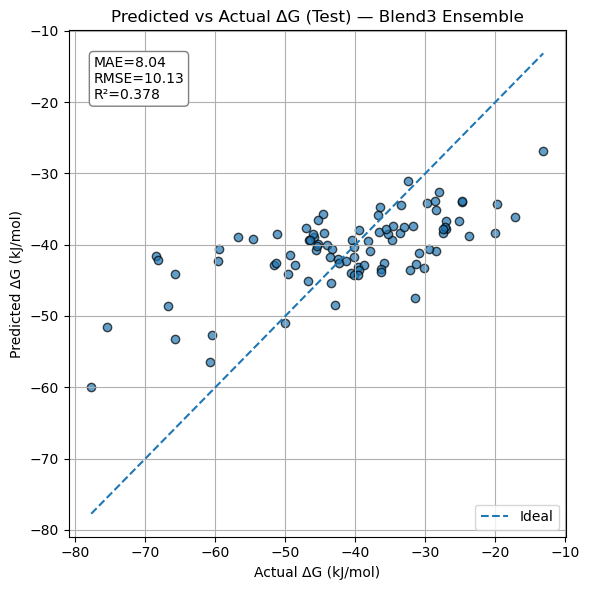

[INFO] Saved plot to: runs/dg_pt_ensemble_rf_et_hgb/pred_vs_actual_test_blend3.png


In [ ]:
# ============================================
# ΔG — single {id}_mGLI.pt — RF + ET + HGB ensemble with richer stacking (fast)
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR  = "./runs/dg_pt_ensemble_rf_et_hgb"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = True
PERCENTILE               = 85          # try 85 to keep a bit more signal
N_TREES_RF               = 800
N_TREES_ET               = 1000
N_SPLITS_STACK           = 5

random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def evaluate(name, y, pred):
    mse  = float(mean_squared_error(y, pred))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y, pred))
    r2   = float(r2_score(y, pred))
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

# Append B-factors if requested
if USE_BFACTORS_AS_FEATURES and bf_cols:
    EX = df_t[bf_cols].to_numpy(dtype=np.float64)
    X_all = np.hstack([X_base, EX])
else:
    X_all = X_base

# ---------- Stratified splits ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Base pipelines ----------
def step_common(percentile=PERCENTILE):
    return [
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=percentile)),
    ]

def make_rf():
    return Pipeline(step_common() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=True,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(step_common() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    # HGB plays well with many weakly-informative features
    return Pipeline(step_common() + [
        ("hgb", HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.06,
            max_depth=4,
            max_leaf_nodes=63,
            min_samples_leaf=20,
            l2_regularization=0.2,
            max_bins=255,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            max_iter=1500,
            random_state=SEED
        ))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

# ---------- Validation ----------
def report_val(name, model):
    pred = model.predict(X_va)
    return evaluate(name, y_va, pred)

print("\n== Validation (base) ==")
_ = report_val("VAL RF", rf)
_ = report_val("VAL ET", et)
_ = report_val("VAL HGB", hgb)

# ---------- OOF stacking with richer meta-features ----------
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))  # [rf, et, hgb, avg3, rf-et, rf-hgb, et-hgb]
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    # accumulate test meta
    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---------- Refit base models on TRAIN+VAL ----------
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

# ---------- Test predictions ----------
pred_te_rf  = rf.predict(X_te)
pred_te_et  = et.predict(X_te)
pred_te_hgb = hgb.predict(X_te)
pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

print("\n== Test (base & ensembles) ==")
_ = evaluate("TEST RF", y_te, pred_te_rf)
_ = evaluate("TEST ET", y_te, pred_te_et)
_ = evaluate("TEST HGB", y_te, pred_te_hgb)
metrics_bl3 = evaluate("TEST Blend(RF+ET+HGB)", y_te, pred_te_bl3)
metrics_st  = evaluate("TEST Stack(Ridge on 7 meta-features)", y_te, pred_te_st)

# ---- Plot best ensemble ----
best_name, best_pred, best_metrics = max(
    [("Blend3", pred_te_bl3, metrics_bl3), ("Stack", pred_te_st, metrics_st)],
    key=lambda x: x[2]["R2"]
)

plt.figure(figsize=(6,6))
plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} Ensemble")
txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True)
plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
print(f"[INFO] Saved plot to: {plot_path}")


In [5]:
import os
import numpy as np
import torch

def diagnose_embeddings(emb_dir, ids_file, n_check=979):
    """Diagnostic function to check embedding quality in .pt files, including all-zero detection"""
    zero_count = 0
    total_checked = 0

    # Read PDB IDs from plain text file
    with open(ids_file, "r") as f:
        pdbs = [line.strip() for line in f if line.strip()]
    
    for pdb in pdbs[:n_check]:  # only check first N
        path = os.path.join(emb_dir, f"{pdb}_mGLI.pt")
        if os.path.exists(path):
            emb = torch.load(path)
            # Handle both tensor and dict cases
            if isinstance(emb, dict):
                emb = next(iter(emb.values()))
            emb_flat = emb.flatten().cpu().numpy()

            all_zero = np.all(emb_flat == 0)
            if all_zero:
                zero_count += 1

            print(f"{pdb}: shape={tuple(emb.shape)}, "
                  f"flat_shape={emb_flat.shape}, "
                  f"has_nan={np.isnan(emb_flat).any()}, "
                  f"has_inf={np.isinf(emb_flat).any()}, "
                  f"min={emb_flat.min():.3f}, "
                  f"max={emb_flat.max():.3f}, "
                  f"all_zero={all_zero}")
            total_checked += 1
        else:
            print(f"{pdb}: File not found")

    print(f"\nSummary: {zero_count} / {total_checked} embeddings are all zeros.")

# Call with your pt2 directory and IDs file
diagnose_embeddings(
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2",
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.txt"
)




/tmp/ipykernel_3402750/1279338094.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb = torch.load(path)


1a22: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=9.430, all_zero=False
1acb: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=3.977, all_zero=False
1ak4: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=2.363, all_zero=False
1an1: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=2.851, all_zero=False
1atn: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=8.521, all_zero=False
1avx: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=5.604, all_zero=False
1avz: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=5.146, all_zero=False
1axi: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=8.909, all_zero=False
1ay7: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=4.603, all_zero=False
1b6c: shape=(1440,), flat_sh

1emv: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=7.224, all_zero=False
1es0: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=18.494, all_zero=False
1ewy: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=4.759, all_zero=False
1ezs: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=11.004, all_zero=False
1ezu: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=0.104, all_zero=False
1f34: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=2.241, all_zero=False
1f3v: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=6.476, all_zero=False
1f5r: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=3.409, all_zero=False
1f7z: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=3.018, all_zero=False
1fc2: shape=(1440,), flat_